# Code for Figure 2 and corresponding supplementary figures

In [1]:
from data import PlateDataset

import torch
import numpy as np
import pandas as pd
from tqdm import trange, tqdm
import matplotlib.pyplot as plt
import torchvision.transforms as T 
import seaborn as sns
import umap


device = 'cuda:0'

In [2]:
data = PlateDataset([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16], load_masks=True, load_dino=True, load_dinobloom=True, load_subcell=True)

  0%|          | 0/16 [00:00<?, ?it/s]

  6%|▋         | 1/16 [00:16<04:09, 16.66s/it]

 12%|█▎        | 2/16 [00:35<04:13, 18.13s/it]

 19%|█▉        | 3/16 [00:42<02:48, 12.93s/it]

 25%|██▌       | 4/16 [01:08<03:35, 17.95s/it]

...

 81%|████████▏ | 13/16 [03:59<01:02, 20.91s/it]

 88%|████████▊ | 14/16 [04:21<00:42, 21.32s/it]

 94%|█████████▍| 15/16 [04:43<00:21, 21.52s/it]

100%|██████████| 16/16 [04:55<00:00, 18.52s/it]

100%|██████████| 16/16 [04:55<00:00, 18.45s/it]

In [3]:
from torchvision.models import resnet18 as make_resnet18
from torchvision.models.feature_extraction import create_feature_extractor
from torch.utils.data import DataLoader


def extract_resnet_patch_features(imgs, transform=None):
  model = make_resnet18(weights="DEFAULT").to(device)
  return_nodes = {
      'flatten': 'z',
  }
  feature_extractor = create_feature_extractor(model.eval().to(device), return_nodes=return_nodes)
  z = torch.zeros((len(imgs), 512))
  i = 0
  loader = DataLoader(imgs, batch_size=128, shuffle=False)
  # for batch in tqdm(loader):
  for img_batch in tqdm(loader):
    img_batch = img_batch.to(device).repeat(1, 3, 1, 1)
    if transform is not None:
      img_batch = transform(img_batch)
    with torch.no_grad():
      z[i:i+len(img_batch)] = feature_extractor(img_batch)['z'].cpu()
    i += len(img_batch)
  return z


import os, numpy as np
_c='results/fig2_res_zs.npy'
if os.path.exists(_c):
    res_zs = torch.from_numpy(np.load(_c))
else:
    res_zs = extract_resnet_patch_features(data.imgs)
    np.save(_c, res_zs.numpy())
res_zs.shape

torch.Size([1093966, 512])

## T1 and healthy UMAPs

In [4]:
# Fig 2 UMAP coordinates + Leiden clusters are precomputed and saved by
# notebooks/umap_and_leiden_clustering.ipynb; here we just load them.
df = pd.read_csv('results/fig_2_umap_with_clusters.csv', index_col=0)
df['plate'] = df['plate'].astype(str)

/tmp/ipykernel_2658650/1821909838.py:3: DtypeWarning: Columns (13) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('results/fig_2_umap_with_clusters.csv', index_col=0)


### Fig 2f

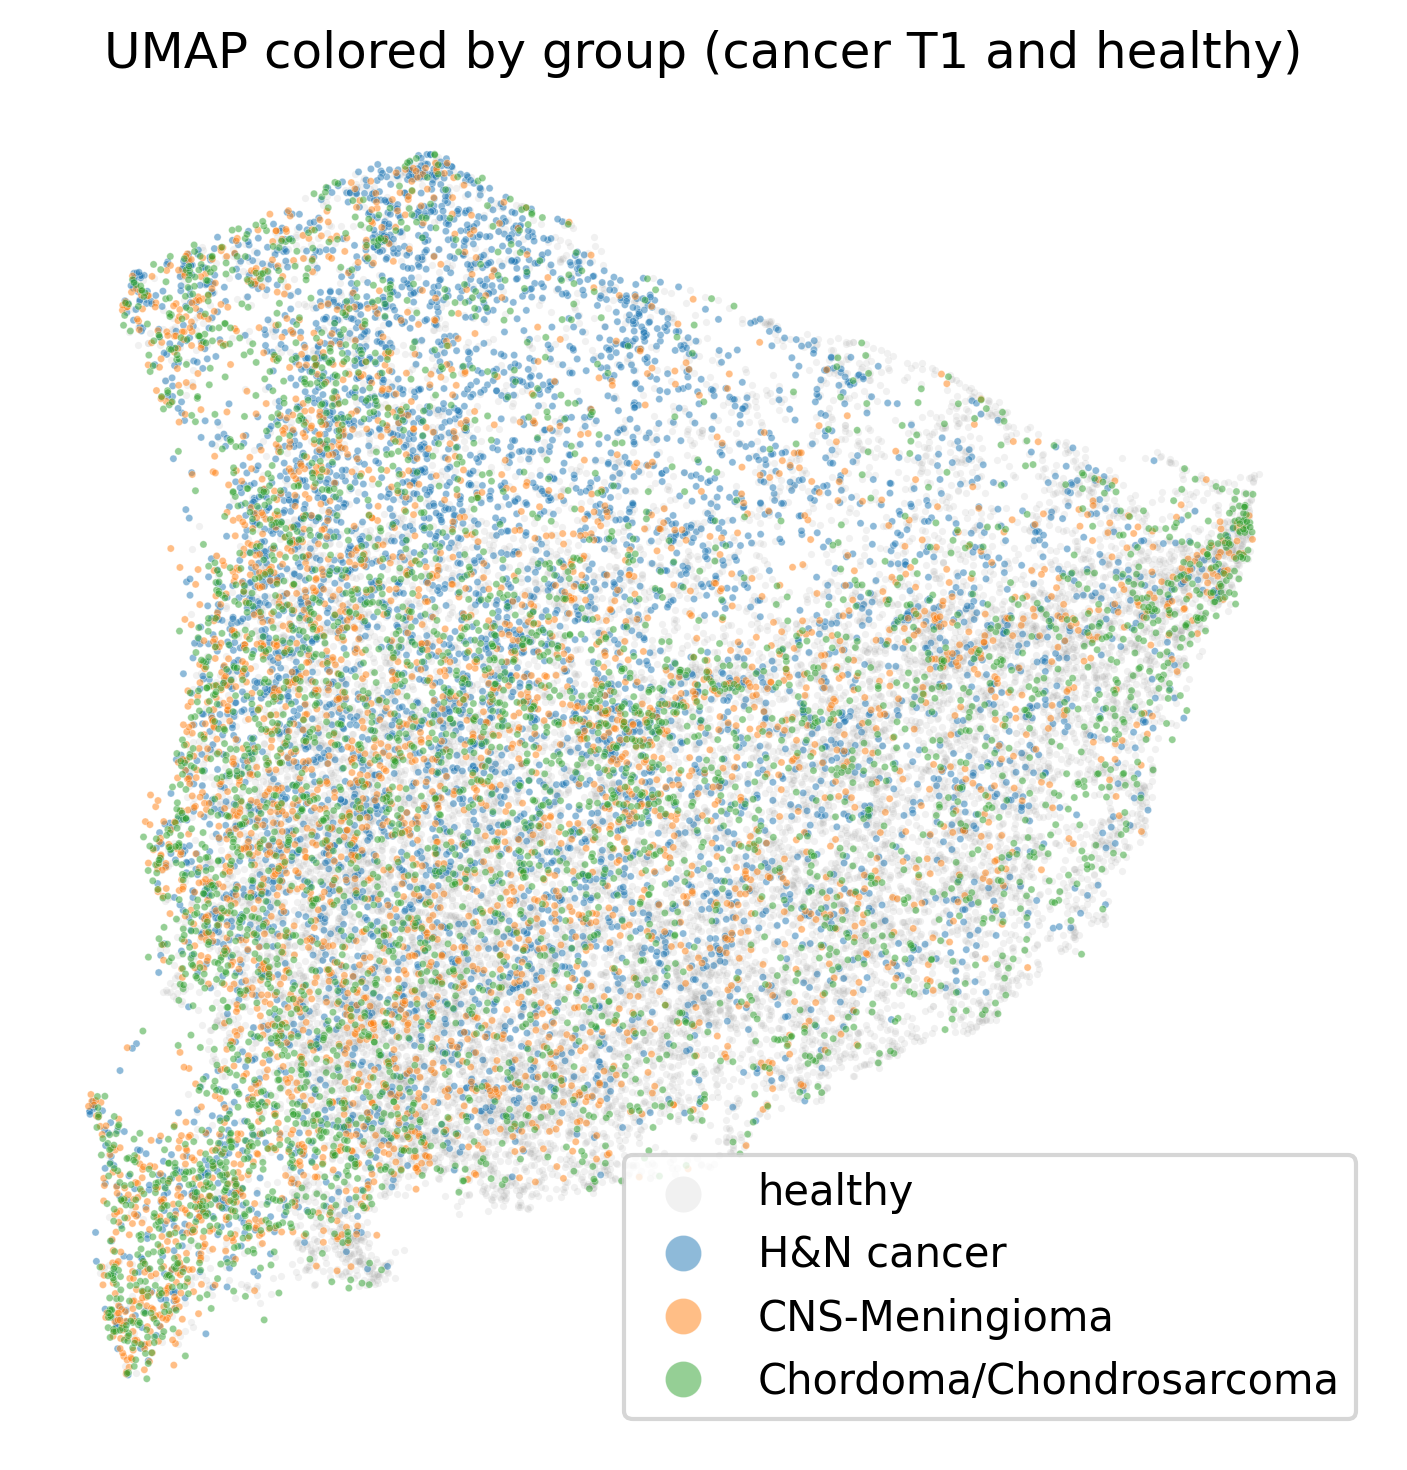

In [5]:
main_groups = ['H&N cancer', 'Chordoma/Chondrosarcoma', 'CNS-Meningioma']

df['main group'] = None
df.loc[df['group'].isin(main_groups), 'main group'] = df.loc[df['group'].isin(main_groups), 'group']
# df.loc[df['diagnosis'] == 'healthy', 'main group'] = 'healthy'

fig, ax = plt.subplots(1, 1, figsize=(9, 5), dpi=300)
m = 'main group'
g = sns.scatterplot(data=df[(df['diagnosis'] == 'healthy') & (df['plate'].astype(int).isin([3, 4, 5, 6, 7, 8, 9, 10, 11, 12]))], 
                    x='umap_x', y='umap_y', label='healthy', color='#7d7f7c', s=3, alpha=0.1, ax=ax)
g = sns.scatterplot(data=df, x='umap_x', y='umap_y', hue=m, s=3, alpha=0.5, ax=ax)
ax.set_title(f'UMAP colored by group (cancer T1 and healthy)')
ax.axis('square')
ax.axis('off')
sns.move_legend(g, 'best', title=None, markerscale=5)

fig.tight_layout()

### Fig. 2e

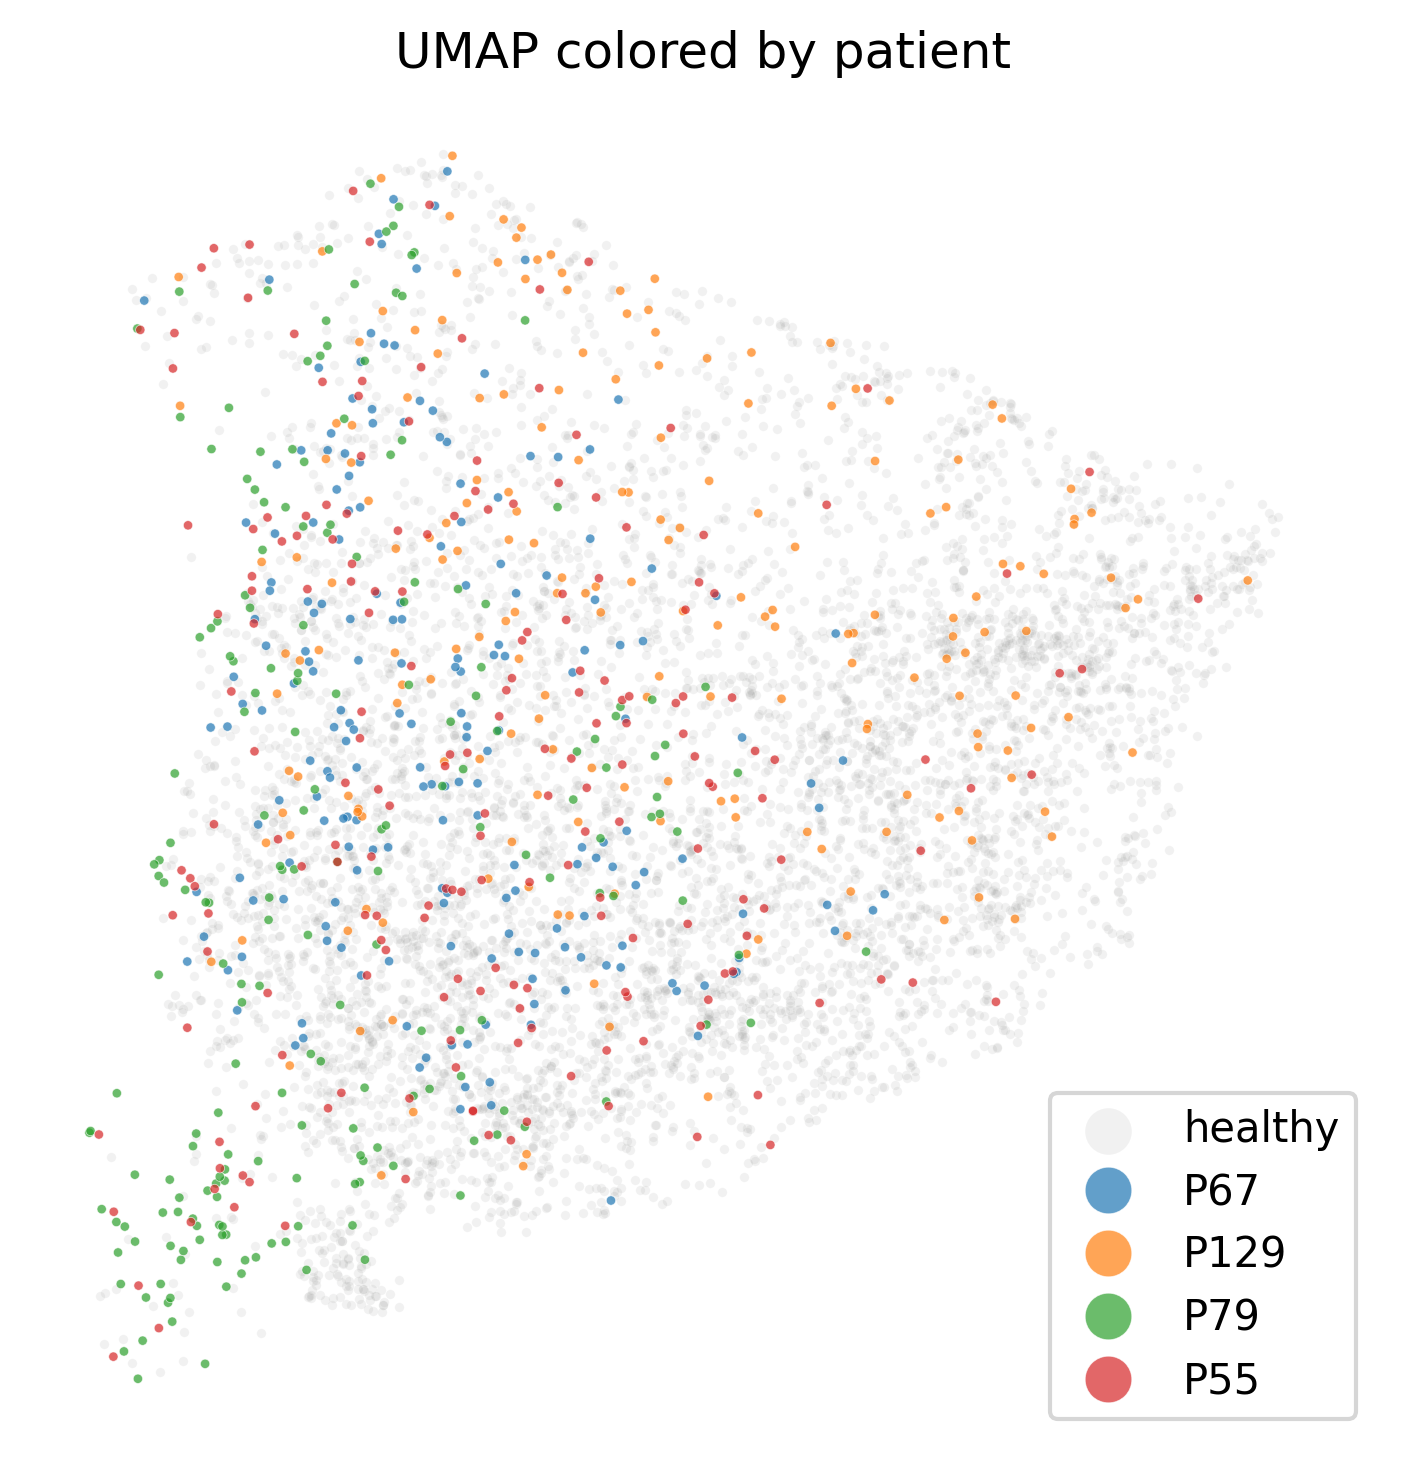

In [6]:
fig, ax = plt.subplots(1, 1, figsize=(9, 5), dpi=300)
m = 'patient'
g = sns.scatterplot(data=df[(df['diagnosis'] == 'healthy') & (df['plate'].astype(int).isin([3, 4, 5, 6]))], 
                    x='umap_x', y='umap_y', label='healthy', color='#7d7f7c', s=5, alpha=0.1, ax=ax)
g = sns.scatterplot(data=df[df['patient'].isin(['P55', 'P67', 'P129', 'P79'])], x='umap_x', y='umap_y', hue=m, s=5, alpha=0.7, ax=ax)
ax.set_title(f'UMAP colored by patient')
ax.axis('square')
ax.axis('off')
sns.move_legend(g, 'best', title=None, markerscale=5)

fig.tight_layout()

### Fig. 2c

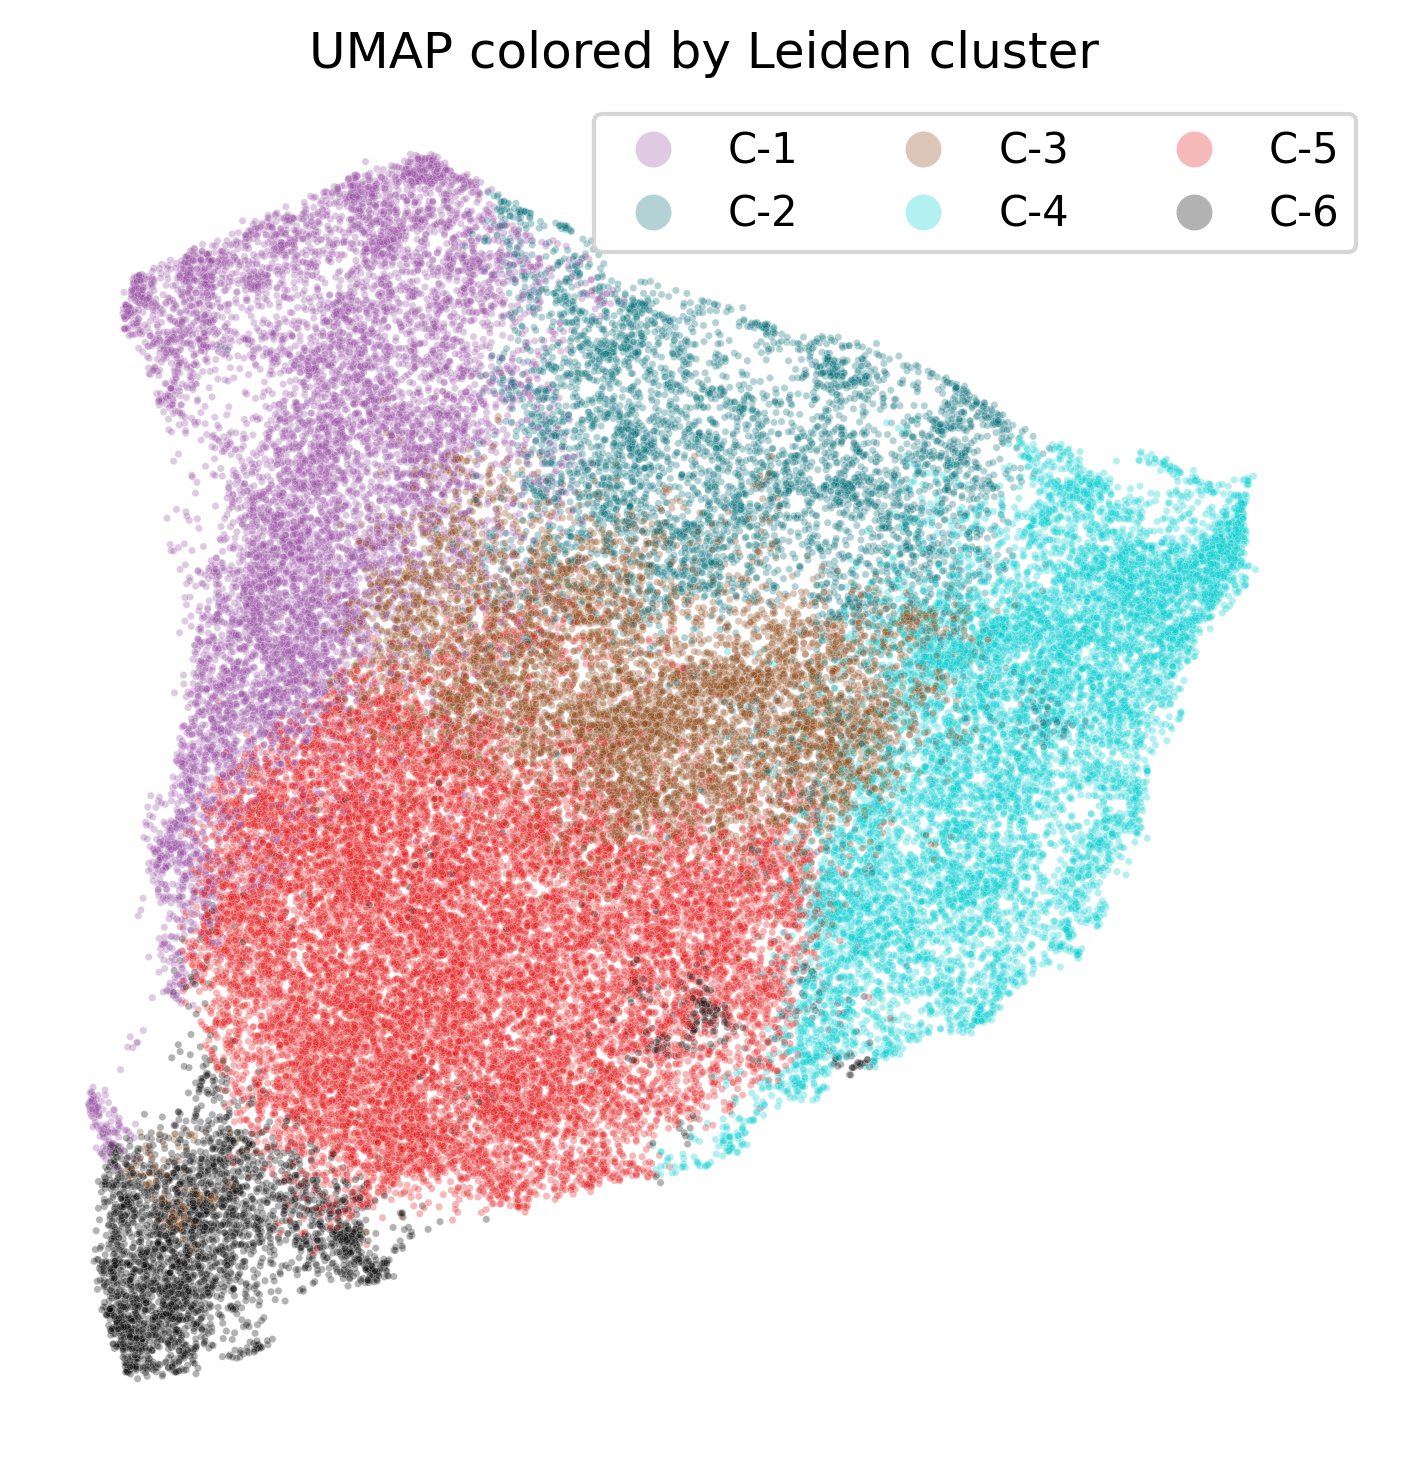

In [7]:
# fig 2c: UMAP colored by Leiden cluster (labels read from the saved umap CSV)
# 6-color palette avoids the cancer/healthy, cancer-type, and fig-5 outcome colors
# (blue/orange/green/gray + magenta/goldenrod)
df['cluster'] = pd.Categorical(df['cluster'], categories=['C-1', 'C-2', 'C-3', 'C-4', 'C-5', 'C-6'])

fig, ax = plt.subplots(1, 1, figsize=(9, 5), dpi=300)
g = sns.scatterplot(data=df, x='umap_x', y='umap_y', hue='cluster',
                    palette=['#984EA3', '#006D77', '#8B4513', '#00CED1', '#E41A1C', '#000000'], s=3, alpha=0.3, ax=ax)
ax.set_title('UMAP colored by Leiden cluster')
ax.axis('square')
ax.axis('off')
sns.move_legend(g, 'upper right', title=None, markerscale=5, ncol=3)

fig.tight_layout()

### Fig. 2d

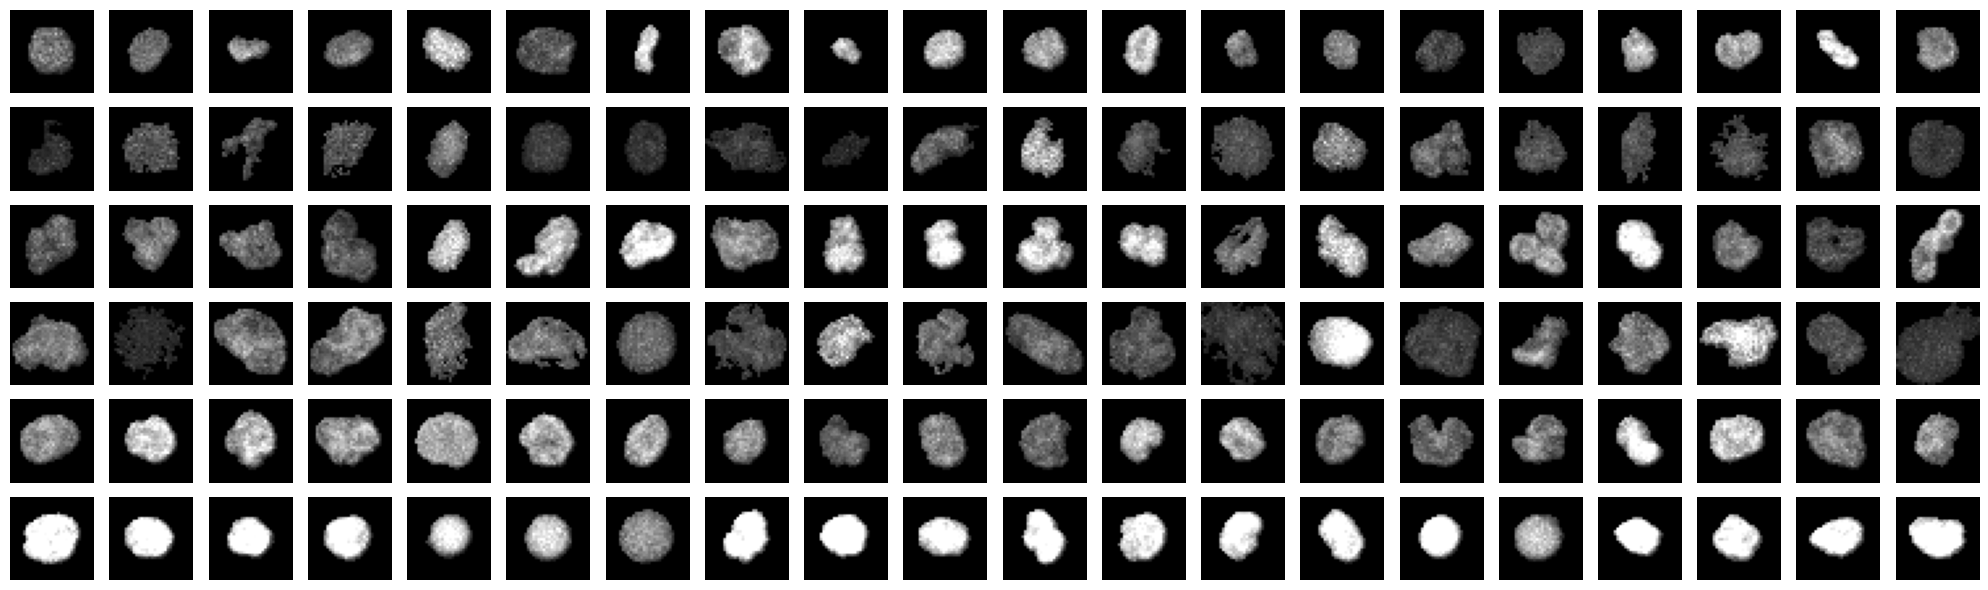

In [8]:
np.random.seed(52343)

fig, axxs = plt.subplots(6, 20, figsize=(20, 6))
for i, c in enumerate(['C-1', 'C-2', 'C-3', 'C-4', 'C-5', 'C-6']):
    idx = np.random.choice(np.argwhere((df['cluster'] == c).values).flatten(), size=20)
    for im, ax in zip(data.imgs[idx] * data.masks[idx], axxs[i]):
        ax.imshow(im.squeeze(), cmap='gray', vmin=0, vmax=1)
        ax.axis('off')
fig.tight_layout()
fig.show()

Text(0.5, 1.0, 'Head & Neck plates only')

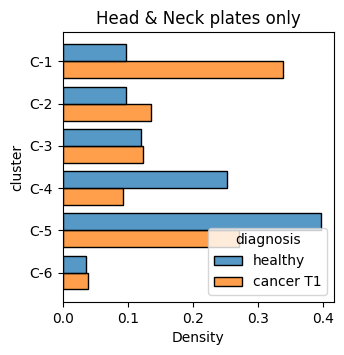

In [9]:
fig, ax = plt.subplots(figsize=(3.5, 3.5))
ax = sns.histplot(data=df[((df['group'] == 'H&N cancer') | (df['diagnosis'] == 'healthy')) & (df['plate'].astype(int).isin([3, 4, 5, 6]))], 
                  y='cluster', hue='diagnosis', common_norm=False, 
                  stat='density', discrete=True, multiple='dodge', shrink=.8, hue_order=['healthy', 'cancer T1'])
sns.move_legend(ax, 'lower right')
ax.set_title('Head & Neck plates only')

## Cancer (time point 1) vs. Healthy cell-level classifiers

In [10]:
from util import torch_random_choice


use_plates = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16])
cdf = data.info[data.info['plate'].isin(use_plates)].groupby(
    ['patient', 'time'])['cell'].count().reset_index()
cdf = cdf[(cdf['cell'] > 100)]

p01s = cdf[(cdf['time'] == 1) | (cdf['time'] == 0)]['patient'].unique()


def test_healthy_vs_cancer_bagloader(bag_size=100, use_patients=p01s, use_times=[0, 1], use_plates=use_plates, device=device, 
                                     transform=T.CenterCrop(28), res_feats=False, dino_feats=False, dinobloom_feats=False, subcell_feats=False):
  use_idx = torch.argwhere(torch.from_numpy((data.info['plate'].isin(use_plates) & data.info['time'].isin(use_times)).values)).flatten()
  use_imgs = transform(data.imgs[use_idx].to(device))
  if res_feats:
    use_data = res_zs[use_idx].to(device)
  elif dino_feats:
    use_data = torch.from_numpy(data.dino_zs[use_idx]).to(device) 
  elif dinobloom_feats:
    use_data = torch.from_numpy(data.dinobloom_zs[use_idx]).to(device)
  elif subcell_feats:
    use_data = torch.from_numpy(data.subcell_zs[use_idx]).to(device)
  else: 
    use_data = use_imgs
  
  pat_plates = data.info.groupby(['patient'])['plate'].unique()
  for pat in use_patients:
    if not np.isin(pat_plates[pat], use_plates).any():
      continue
    pat_idx = torch.argwhere(torch.from_numpy((data.info.loc[use_idx]['patient'] == pat).values)).flatten().to(device)
    idx = torch_random_choice(pat_idx, size=bag_size)
    xs = use_data[idx]
    label = 1 if pat[0] == 'H' else 0
    yield xs.float(), use_imgs[idx].float(), torch.tensor(label).to(device), pat, 'healthy' if pat[0] == 'H' else 'cancer'

In [11]:
from models import FeatClassifier


def eval_model(name, loader, model, feats=True):
    model = model.to(device)
    model.load_state_dict(torch.load(f'/ewsc/hschluet/models/pbmc5/revision_rerun/{name}_model.pt', weights_only=True, map_location=device))
    model.eval()

    np.random.seed(1232412)
    torch.manual_seed(124514)
    torch.cuda.manual_seed_all(13513)

    bag_labs = []
    bag_pred = []
    bag_ids = []
    bag_zs = []
    bag_pats = []
    bag_groups = []
    bags = []
    for i, (z, bag, lab, pat, group) in enumerate(loader):
        with torch.no_grad():
            _, pred, z = model(z.to(device)) if feats else model(bag.to(device))
        bag_ids.extend([i] * 100)
        bag_pats.extend([pat] * 100)
        bag_groups.extend([group] * 100)
        bag_labs.extend([lab.item()] * 100)
        bag_pred.extend(pred.cpu().numpy())
        bag_zs.extend(z.cpu().numpy())
        bags.extend(bag.cpu().numpy())

    df = pd.DataFrame()
    df['lab'] = bag_labs
    df['pred'] = bag_pred
    df['i'] = bag_ids
    df['pat'] = bag_pats
    df['group'] = bag_groups
    return df, bag_zs, bags

### Fig. S2a

In [12]:
dfs = []

for plate in tqdm(use_plates):
  df, _, _ = eval_model(f'1_16_t01_healthy_cancer_without_plate_{plate}_by_cell_pretrained_resnet', 
                        test_healthy_vs_cancer_bagloader(use_plates=[plate], res_feats=True), FeatClassifier())
  df['plate'] = plate
  dfs.append(df)


res_without_df = pd.concat(dfs, ignore_index=True)
pat_df = pd.DataFrame()
pat_df['counts'] = res_without_df.groupby(['plate', 'pat', 'group'])['pred'].value_counts() 
pat_df = pat_df.reset_index()
pat_df

  0%|          | 0/16 [00:00<?, ?it/s]

  6%|▋         | 1/16 [00:00<00:11,  1.29it/s]

 12%|█▎        | 2/16 [00:00<00:06,  2.25it/s]

 19%|█▉        | 3/16 [00:01<00:04,  2.63it/s]

 25%|██▌       | 4/16 [00:01<00:03,  3.03it/s]

...

 88%|████████▊ | 14/16 [00:03<00:00,  3.89it/s]

 94%|█████████▍| 15/16 [00:04<00:00,  4.10it/s]

100%|██████████| 16/16 [00:04<00:00,  4.38it/s]

100%|██████████| 16/16 [00:04<00:00,  3.65it/s]

,plate,pat,group,pred,counts
0,1,H01,healthy,0.0,51
1,1,H01,healthy,1.0,49
2,1,H02,healthy,1.0,80
3,1,H02,healthy,0.0,20
4,1,H03,healthy,1.0,64
...,...,...,...,...,...
393,16,P151,cancer,0.0,100
394,16,P45,cancer,0.0,100
395,16,P61,cancer,0.0,99
396,16,P61,cancer,1.0,1


In [13]:
import os

def cm_metrics(mat):
    """(macro-F1, balanced accuracy) from a COUNT confusion matrix (rows=true, cols=pred)."""
    C = np.nan_to_num(np.asarray(mat.reindex(columns=list(mat.index)), dtype=float))
    tp = np.diag(C); row = C.sum(1); col = C.sum(0)
    with np.errstate(divide='ignore', invalid='ignore'):
        rec = np.where(row > 0, tp / row, np.nan)
        prec = np.where(col > 0, tp / col, np.nan)
        f1 = np.where((prec + rec) > 0, 2 * prec * rec / (prec + rec), 0.0)
    return np.nanmean(np.where(row > 0, f1, np.nan)), np.nanmean(rec)

def cm_metrics_title(mat):
    return 'mF1={:.2f}, BA={:.2f}'.format(*cm_metrics(mat))

def cm_ba_title(mat):
    """Balanced accuracy (mean recall) from a COUNT confusion matrix."""
    return 'BA={:.2f}'.format(cm_metrics(mat)[1])

def soft_ba_title(mat):
    """Balanced accuracy from a row-normalized (soft) confusion matrix = mean of the diagonal."""
    M = np.asarray(mat.reindex(columns=list(mat.index)), dtype=float)
    return 'BA={:.2f}'.format(np.nanmean(np.diag(M)))

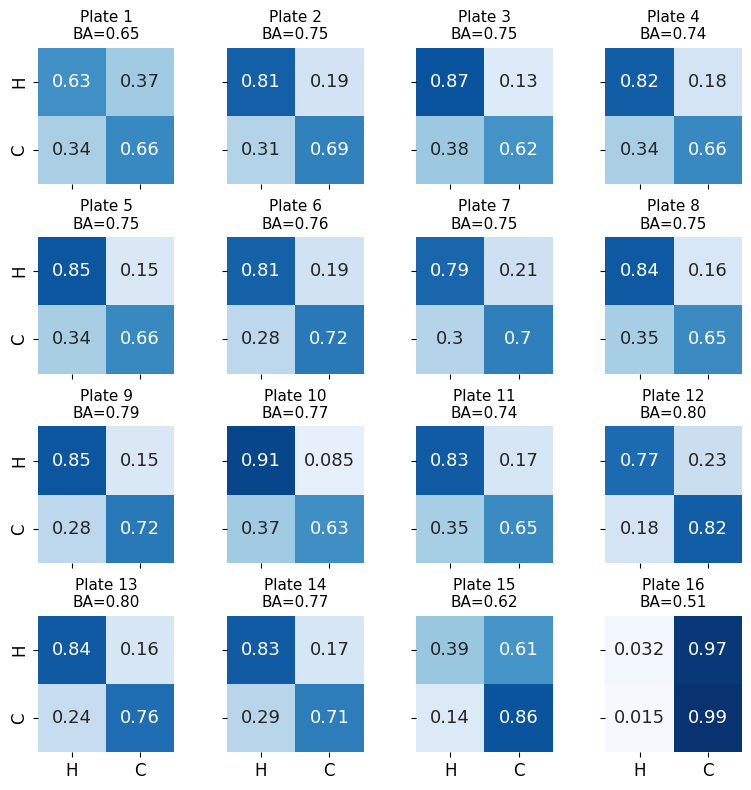

In [14]:
pat_df = res_without_df.groupby(['plate', 'pat', 'group'])['pred'].mean().reset_index()
plate_df = pat_df.groupby(['plate', 'group'])['pred'].mean().reset_index()
plate_df.loc[plate_df['group'] != 'healthy', 'group'] = 'C'
plate_df.loc[plate_df['group'] == 'healthy', 'group'] = 'H'
plate_df['group'] = pd.Categorical(values=plate_df['group'], categories=['H', 'C'])
plate_df['H'] = plate_df['pred']
plate_df['C'] = 1 - plate_df['H']


fig, axs = plt.subplots(4, 4, figsize=(8, 8), sharex=True, sharey=True)
for ax, plate in zip(axs.flatten(), use_plates):
    # mat = pat_df[pat_df['plate'] == plate].groupby(
    #     ['group', 'pred'])['pat'].count().reset_index().pivot(index='group', columns='pred', values='pat')
    # sns.heatmap(mat, ax=ax, annot=True)
    mat = plate_df[plate_df['plate'] == plate].set_index('group').loc[['H', 'C'], ['H', 'C']]
    sns.heatmap(mat.div(mat.sum(axis=1), axis=0), annot=mat, ax=ax, vmin=0, vmax=1, cbar=False, cmap='Blues', square=True, annot_kws={'size': 13})
    ax.tick_params(labelsize=12)
    ax.set_ylabel('')
    ax.set_xlabel('')
    ax.set_title(f'Plate {plate}' + '\n' + soft_ba_title(mat), fontsize=11)
fig.tight_layout()

### Fig. 2b

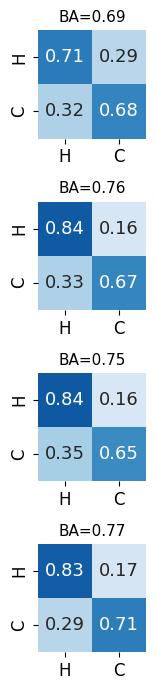

In [15]:
pat_df = res_without_df.groupby(['plate', 'pat', 'group'])['pred'].mean().reset_index()
diag = pd.read_csv('meta/patient_diagnosis_groups.csv').rename(columns={'patient':'pat', 'group':'diag'})
pat_df = pat_df.merge(diag, on='pat', how='left').set_index('pat')
pat_df.loc[pat_df['group'] == 'healthy', 'diag'] = 'healthy'

diags = ['CNS-Glioma', 'H&N cancer', 'Chordoma/Chondrosarcoma', 'CNS-Meningioma']
plates = [[1, 2], [3, 4, 5, 6], [10, 11, 12], [7, 8, 9]]

for d, ps in zip(diags, plates):
    pat_df.loc[pat_df['plate'].isin(ps) & ((pat_df['diag'] == d) | (pat_df['group'] == 'healthy')), 'diag_group'] = d

diag_df = pat_df.groupby(['diag_group', 'group'])['pred'].mean().reset_index()
diag_df.loc[diag_df['group'] != 'healthy', 'group'] = 'C'
diag_df.loc[diag_df['group'] == 'healthy', 'group'] = 'H'
diag_df['group'] = pd.Categorical(values=diag_df['group'], categories=['H', 'C'])
diag_df['H'] = diag_df['pred']
diag_df['C'] = 1 - diag_df['H']

fig, axs = plt.subplots(4, 1, figsize=(2.8, 7))
for ax, d, ps in zip(axs.flatten(), diags, plates):
    mat = diag_df[diag_df['diag_group'] == d].set_index('group').loc[['H', 'C'], ['H', 'C']]
    sns.heatmap(mat.div(mat.sum(axis=1), axis=0), annot=mat, ax=ax, vmin=0, vmax=1, cbar=False, cmap='Blues', square=True, annot_kws={'size': 13})
    ax.tick_params(labelsize=12)
    ax.set_title(soft_ba_title(mat), fontsize=11)
    ax.set_ylabel('')
    ax.set_xlabel('')
fig.tight_layout()

### Fig. S2b

/tmp/ipykernel_2658650/3542276991.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mat = pat_df.reset_index()[((pat_df.reset_index()['diag'] == d) | (pat_df.reset_index()['group'] == 'H'))].groupby(
/tmp/ipykernel_2658650/3542276991.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mat = pat_df.reset_index()[((pat_df.reset_index()['diag'] == d) | (pat_df.reset_index()['group'] == 'H'))].groupby(
/tmp/ipykernel_2658650/3542276991.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or o

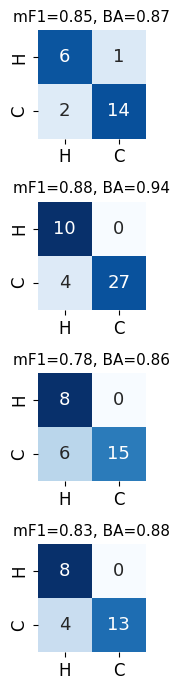

In [16]:
diags = ['CNS-Glioma', 'H&N cancer', 'Chordoma/Chondrosarcoma', 'CNS-Meningioma']
plates = [[1, 2], [3, 4, 5, 6], [10, 11, 12], [7, 8, 9]]
diag = pd.read_csv('meta/patient_diagnosis_groups.csv').rename(columns={'patient':'pat', 'group':'diag'})

fig, axs = plt.subplots(4, 1, figsize=(2.8, 7))
for ax, d, ps in zip(axs.flatten(), diags, plates):
    pat_df = res_without_df[res_without_df['plate'].isin(ps)]
    pat_df = pat_df.merge(diag, on='pat', how='left').set_index('pat')
    pat_df.loc[pat_df['group'] == 'healthy', 'diag'] = 'healthy'
    pat_df = pat_df.groupby(['pat', 'group', 'diag'])['pred'].agg(lambda x : x.mode(dropna=True)[0]).dropna().reset_index()
    pat_df.loc[pat_df['pred'] == 0, 'pred_group'] = 'C'
    pat_df.loc[pat_df['pred'] == 1, 'pred_group'] = 'H'
    pat_df['group'] = pat_df['group'].replace({'healthy' : 'H', 'cancer' : 'C'})
    pat_df['group'] = pd.Categorical(values=pat_df['group'], categories=['H', 'C'])
    pat_df['pred_group'] = pd.Categorical(values=pat_df['pred_group'], categories=['H', 'C'])
    
    mat = pat_df.reset_index()[((pat_df.reset_index()['diag'] == d) | (pat_df.reset_index()['group'] == 'H'))].groupby(
        ['group', 'pred_group'])['pat'].count().reset_index().pivot(index='group', columns='pred_group', values='pat')
    sns.heatmap(mat.div(mat.sum(axis=1), axis=0), annot=mat, ax=ax, vmin=0, vmax=1, cbar=False, cmap='Blues', square=True, annot_kws={'size': 13})
    ax.tick_params(labelsize=12)
    ax.set_title(cm_metrics_title(mat), fontsize=11)
    ax.set_ylabel('')
    ax.set_xlabel('')
fig.tight_layout()

### Fig. S2e (simple convnet)

In [17]:
from models import Classifier
import os

_cache = 'results/fig2_cell_hc_predictions.csv'  # also used by Supplementary Fig. S8; a cached read is identical to a fresh eval
if os.path.exists(_cache):
    res_without_df = pd.read_csv(_cache)
else:
    dfs = []
    for plate in tqdm(use_plates):
      df, _, _ = eval_model(f'1_16_t01_healthy_cancer_without_plate_{plate}_by_cell_mil_architecture', 
                            test_healthy_vs_cancer_bagloader(use_plates=[plate]), Classifier(), feats=False)
      df['plate'] = plate
      dfs.append(df)
    res_without_df = pd.concat(dfs, ignore_index=True)
    res_without_df.to_csv(_cache, index=False)
pat_df = pd.DataFrame()
pat_df['counts'] = res_without_df.groupby(['plate', 'pat', 'group'])['pred'].value_counts() 
pat_df = pat_df.reset_index()
pat_df

  0%|          | 0/16 [00:00<?, ?it/s]

  6%|▋         | 1/16 [00:00<00:09,  1.50it/s]

 12%|█▎        | 2/16 [00:00<00:05,  2.43it/s]

 19%|█▉        | 3/16 [00:01<00:04,  3.07it/s]

 25%|██▌       | 4/16 [00:01<00:03,  3.34it/s]

...

 88%|████████▊ | 14/16 [00:04<00:00,  3.64it/s]

 94%|█████████▍| 15/16 [00:04<00:00,  3.77it/s]

100%|██████████| 16/16 [00:04<00:00,  4.02it/s]

100%|██████████| 16/16 [00:04<00:00,  3.48it/s]

,plate,pat,group,pred,counts
0,1,H01,healthy,1.0,81
1,1,H01,healthy,0.0,19
2,1,H02,healthy,1.0,88
3,1,H02,healthy,0.0,12
4,1,H03,healthy,1.0,78
...,...,...,...,...,...
385,16,P151,cancer,0.0,99
386,16,P151,cancer,1.0,1
387,16,P45,cancer,0.0,100
388,16,P61,cancer,0.0,100


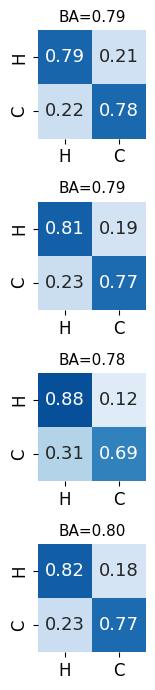

In [18]:
pat_df = res_without_df.groupby(['plate', 'pat', 'group'])['pred'].mean().reset_index()
diag = pd.read_csv('meta/patient_diagnosis_groups.csv').rename(columns={'patient':'pat', 'group':'diag'})
pat_df = pat_df.merge(diag, on='pat', how='left').set_index('pat')
pat_df.loc[pat_df['group'] == 'healthy', 'diag'] = 'healthy'

diags = ['CNS-Glioma', 'H&N cancer', 'Chordoma/Chondrosarcoma', 'CNS-Meningioma']
plates = [[1, 2], [3, 4, 5, 6], [10, 11, 12], [7, 8, 9]]

for d, ps in zip(diags, plates):
    pat_df.loc[pat_df['plate'].isin(ps) & ((pat_df['diag'] == d) | (pat_df['group'] == 'healthy')), 'diag_group'] = d

diag_df = pat_df.groupby(['diag_group', 'group'])['pred'].mean().reset_index()
diag_df.loc[diag_df['group'] != 'healthy', 'group'] = 'C'
diag_df.loc[diag_df['group'] == 'healthy', 'group'] = 'H'
diag_df['group'] = pd.Categorical(values=diag_df['group'], categories=['H', 'C'])
diag_df['H'] = diag_df['pred']
diag_df['C'] = 1 - diag_df['H']

fig, axs = plt.subplots(4, 1, figsize=(2.8, 7))
for ax, d, ps in zip(axs.flatten(), diags, plates):
    mat = diag_df[diag_df['diag_group'] == d].set_index('group').loc[['H', 'C'], ['H', 'C']]
    sns.heatmap(mat.div(mat.sum(axis=1), axis=0), annot=mat, ax=ax, vmin=0, vmax=1, cbar=False, cmap='Blues', square=True, annot_kws={'size': 13})
    ax.tick_params(labelsize=12)
    ax.set_title(soft_ba_title(mat), fontsize=11)
    ax.set_ylabel('')
    ax.set_xlabel('')
fig.tight_layout()

### Fig. S2e (resnet from scratch)

In [19]:
def eval_resnet(name, loader, classes=5):
    model = make_resnet18(num_classes=classes).to(device)
    model.load_state_dict(torch.load(f'/ewsc/hschluet/models/pbmc5/revision_rerun/{name}_model.pt', weights_only=True, map_location=device))
    model.eval()

    np.random.seed(1232412)
    torch.manual_seed(124514)
    torch.cuda.manual_seed_all(13513)

    bag_labs = []
    bag_pred = []
    bag_ids = []
    bag_zs = []
    bag_pats = []
    bag_groups = []
    bags = []
    for i, (_, bag, lab, pat, group) in enumerate(loader):
        with torch.no_grad():
            prob = model(bag.repeat(1, 3, 1, 1).to(device))
            pred = torch.argmax(prob, dim=-1)
        bag_ids.extend([i] * 100)
        bag_pats.extend([pat] * 100)
        bag_groups.extend([group] * 100)
        bag_labs.extend([lab.item()] * 100)
        bag_pred.extend(pred.cpu().numpy())
        # bag_zs.extend(z.cpu().numpy())
        bags.extend(bag.cpu().numpy())

    df = pd.DataFrame()
    df['lab'] = bag_labs
    df['pred'] = bag_pred
    df['i'] = bag_ids
    df['pat'] = bag_pats
    df['group'] = bag_groups
    return df, bag_zs, bags

In [20]:
dfs = []

for plate in tqdm(use_plates):
  df, _, _ = eval_resnet(f'1_16_t01_healthy_cancer_without_plate_{plate}_by_cell_resnet_from_scratch', 
                        test_healthy_vs_cancer_bagloader(use_plates=[plate]), classes=2)
  df['plate'] = plate
  dfs.append(df)


res_without_df = pd.concat(dfs, ignore_index=True)
pat_df = pd.DataFrame()
pat_df['counts'] = res_without_df.groupby(['plate', 'pat', 'group'])['pred'].value_counts() 
pat_df = pat_df.reset_index()
pat_df

  0%|          | 0/16 [00:00<?, ?it/s]

  6%|▋         | 1/16 [00:01<00:29,  1.94s/it]

 12%|█▎        | 2/16 [00:03<00:19,  1.42s/it]

 19%|█▉        | 3/16 [00:03<00:14,  1.15s/it]

 25%|██▌       | 4/16 [00:05<00:15,  1.32s/it]

...

 88%|████████▊ | 14/16 [00:15<00:01,  1.02it/s]

 94%|█████████▍| 15/16 [00:16<00:01,  1.01s/it]

100%|██████████| 16/16 [00:17<00:00,  1.01it/s]

100%|██████████| 16/16 [00:17<00:00,  1.07s/it]

,plate,pat,group,pred,counts
0,1,H01,healthy,1,56
1,1,H01,healthy,0,44
2,1,H02,healthy,1,77
3,1,H02,healthy,0,23
4,1,H03,healthy,1,64
...,...,...,...,...,...
371,16,P139,cancer,0,100
372,16,P151,cancer,0,100
373,16,P45,cancer,0,100
374,16,P61,cancer,0,100


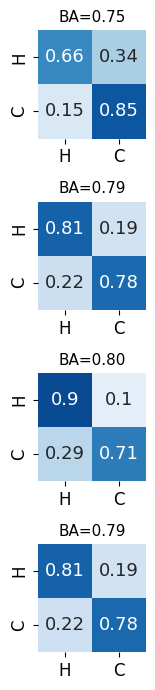

In [21]:
pat_df = res_without_df.groupby(['plate', 'pat', 'group'])['pred'].mean().reset_index()
diag = pd.read_csv('meta/patient_diagnosis_groups.csv').rename(columns={'patient':'pat', 'group':'diag'})
pat_df = pat_df.merge(diag, on='pat', how='left').set_index('pat')
pat_df.loc[pat_df['group'] == 'healthy', 'diag'] = 'healthy'

diags = ['CNS-Glioma', 'H&N cancer', 'Chordoma/Chondrosarcoma', 'CNS-Meningioma']
plates = [[1, 2], [3, 4, 5, 6], [10, 11, 12], [7, 8, 9]]

for d, ps in zip(diags, plates):
    pat_df.loc[pat_df['plate'].isin(ps) & ((pat_df['diag'] == d) | (pat_df['group'] == 'healthy')), 'diag_group'] = d

diag_df = pat_df.groupby(['diag_group', 'group'])['pred'].mean().reset_index()
diag_df.loc[diag_df['group'] != 'healthy', 'group'] = 'C'
diag_df.loc[diag_df['group'] == 'healthy', 'group'] = 'H'
diag_df['group'] = pd.Categorical(values=diag_df['group'], categories=['H', 'C'])
diag_df['H'] = diag_df['pred']
diag_df['C'] = 1 - diag_df['H']

fig, axs = plt.subplots(4, 1, figsize=(2.8, 7))
for ax, d, ps in zip(axs.flatten(), diags, plates):
    mat = diag_df[diag_df['diag_group'] == d].set_index('group').loc[['H', 'C'], ['H', 'C']]
    sns.heatmap(mat.div(mat.sum(axis=1), axis=0), annot=mat, ax=ax, vmin=0, vmax=1, cbar=False, cmap='Blues', square=True, annot_kws={'size': 13})
    ax.tick_params(labelsize=12)
    ax.set_title(soft_ba_title(mat), fontsize=11)
    ax.set_ylabel('')
    ax.set_xlabel('')
fig.tight_layout()

### Fig. S2e (pre-trained DINO)

In [22]:
dfs = []

for plate in tqdm(use_plates):
  df, _, _ = eval_model(f'1_16_t01_healthy_cancer_without_plate_{plate}_by_cell_pretrained_dino', 
                        test_healthy_vs_cancer_bagloader(use_plates=[plate], dino_feats=True), FeatClassifier(input_dim=384))
  df['plate'] = plate
  dfs.append(df)


res_without_df = pd.concat(dfs, ignore_index=True)
pat_df = pd.DataFrame()
pat_df['counts'] = res_without_df.groupby(['plate', 'pat', 'group'])['pred'].value_counts() 
pat_df = pat_df.reset_index()
pat_df

  0%|          | 0/16 [00:00<?, ?it/s]

  6%|▋         | 1/16 [00:00<00:04,  3.07it/s]

 12%|█▎        | 2/16 [00:00<00:03,  4.02it/s]

 19%|█▉        | 3/16 [00:00<00:02,  4.59it/s]

 25%|██▌       | 4/16 [00:01<00:03,  3.86it/s]

...

 88%|████████▊ | 14/16 [00:03<00:00,  3.68it/s]

 94%|█████████▍| 15/16 [00:03<00:00,  4.09it/s]

100%|██████████| 16/16 [00:03<00:00,  4.24it/s]

100%|██████████| 16/16 [00:03<00:00,  4.05it/s]

,plate,pat,group,pred,counts
0,1,H01,healthy,1.0,60
1,1,H01,healthy,0.0,40
2,1,H02,healthy,1.0,73
3,1,H02,healthy,0.0,27
4,1,H03,healthy,1.0,69
...,...,...,...,...,...
394,16,P45,cancer,0.0,99
395,16,P45,cancer,1.0,1
396,16,P61,cancer,0.0,90
397,16,P61,cancer,1.0,10


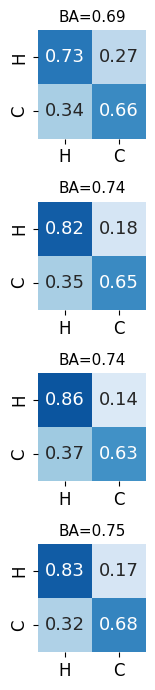

In [23]:
pat_df = res_without_df.groupby(['plate', 'pat', 'group'])['pred'].mean().reset_index()
diag = pd.read_csv('meta/patient_diagnosis_groups.csv').rename(columns={'patient':'pat', 'group':'diag'})
pat_df = pat_df.merge(diag, on='pat', how='left').set_index('pat')
pat_df.loc[pat_df['group'] == 'healthy', 'diag'] = 'healthy'

diags = ['CNS-Glioma', 'H&N cancer', 'Chordoma/Chondrosarcoma', 'CNS-Meningioma']
plates = [[1, 2], [3, 4, 5, 6], [10, 11, 12], [7, 8, 9]]

for d, ps in zip(diags, plates):
    pat_df.loc[pat_df['plate'].isin(ps) & ((pat_df['diag'] == d) | (pat_df['group'] == 'healthy')), 'diag_group'] = d

diag_df = pat_df.groupby(['diag_group', 'group'])['pred'].mean().reset_index()
diag_df.loc[diag_df['group'] != 'healthy', 'group'] = 'C'
diag_df.loc[diag_df['group'] == 'healthy', 'group'] = 'H'
diag_df['group'] = pd.Categorical(values=diag_df['group'], categories=['H', 'C'])
diag_df['H'] = diag_df['pred']
diag_df['C'] = 1 - diag_df['H']

fig, axs = plt.subplots(4, 1, figsize=(2.8, 7))
for ax, d, ps in zip(axs.flatten(), diags, plates):
    mat = diag_df[diag_df['diag_group'] == d].set_index('group').loc[['H', 'C'], ['H', 'C']]
    sns.heatmap(mat.div(mat.sum(axis=1), axis=0), annot=mat, ax=ax, vmin=0, vmax=1, cbar=False, cmap='Blues', square=True, annot_kws={'size': 13})
    ax.tick_params(labelsize=12)
    ax.set_title(soft_ba_title(mat), fontsize=11)
    ax.set_ylabel('')
    ax.set_xlabel('')
fig.tight_layout()

### Fig. S2e (DinoBloom-S)

  0%|          | 0/16 [00:00<?, ?it/s]

  6%|▋         | 1/16 [00:00<00:02,  5.99it/s]

 12%|█▎        | 2/16 [00:00<00:02,  5.58it/s]

 19%|█▉        | 3/16 [00:00<00:02,  5.86it/s]

 25%|██▌       | 4/16 [00:00<00:02,  5.16it/s]

...

 81%|████████▏ | 13/16 [00:02<00:00,  4.48it/s]

 88%|████████▊ | 14/16 [00:02<00:00,  4.66it/s]

 94%|█████████▍| 15/16 [00:03<00:00,  4.44it/s]

100%|██████████| 16/16 [00:03<00:00,  4.86it/s]

100%|██████████| 16/16 [00:03<00:00,  4.84it/s]

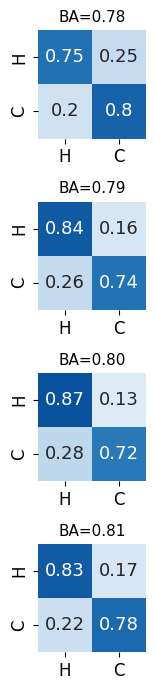

In [24]:
dfs = []

for plate in tqdm(use_plates):
  df, _, _ = eval_model(f'1_16_t01_healthy_cancer_without_plate_{plate}_by_cell_pretrained_dinobloom', 
                        test_healthy_vs_cancer_bagloader(use_plates=[plate], dinobloom_feats=True), FeatClassifier(input_dim=384))
  df['plate'] = plate
  dfs.append(df)


res_without_df = pd.concat(dfs, ignore_index=True)

pat_df = res_without_df.groupby(['plate', 'pat', 'group'])['pred'].mean().reset_index()
diag = pd.read_csv('meta/patient_diagnosis_groups.csv').rename(columns={'patient':'pat', 'group':'diag'})
pat_df = pat_df.merge(diag, on='pat', how='left').set_index('pat')
pat_df.loc[pat_df['group'] == 'healthy', 'diag'] = 'healthy'

diags = ['CNS-Glioma', 'H&N cancer', 'Chordoma/Chondrosarcoma', 'CNS-Meningioma']
plates = [[1, 2], [3, 4, 5, 6], [10, 11, 12], [7, 8, 9]]

for d, ps in zip(diags, plates):
    pat_df.loc[pat_df['plate'].isin(ps) & ((pat_df['diag'] == d) | (pat_df['group'] == 'healthy')), 'diag_group'] = d

diag_df = pat_df.groupby(['diag_group', 'group'])['pred'].mean().reset_index()
diag_df.loc[diag_df['group'] != 'healthy', 'group'] = 'C'
diag_df.loc[diag_df['group'] == 'healthy', 'group'] = 'H'
diag_df['group'] = pd.Categorical(values=diag_df['group'], categories=['H', 'C'])
diag_df['H'] = diag_df['pred']
diag_df['C'] = 1 - diag_df['H']

fig, axs = plt.subplots(4, 1, figsize=(2.8, 7))
for ax, d, ps in zip(axs.flatten(), diags, plates):
    mat = diag_df[diag_df['diag_group'] == d].set_index('group').loc[['H', 'C'], ['H', 'C']]
    sns.heatmap(mat.div(mat.sum(axis=1), axis=0), annot=mat, ax=ax, vmin=0, vmax=1, cbar=False, cmap='Blues', square=True, annot_kws={'size': 13})
    ax.tick_params(labelsize=12)
    ax.set_title(soft_ba_title(mat), fontsize=11)
    ax.set_ylabel('')
    ax.set_xlabel('')
fig.tight_layout()

### Fig. S2e (SubCell)

  0%|          | 0/16 [00:00<?, ?it/s]

  6%|▋         | 1/16 [00:01<00:15,  1.01s/it]

 12%|█▎        | 2/16 [00:01<00:12,  1.16it/s]

 19%|█▉        | 3/16 [00:02<00:10,  1.29it/s]

 25%|██▌       | 4/16 [00:03<00:10,  1.15it/s]

...

 81%|████████▏ | 13/16 [00:11<00:02,  1.14it/s]

 88%|████████▊ | 14/16 [00:11<00:01,  1.13it/s]

 94%|█████████▍| 15/16 [00:12<00:00,  1.14it/s]

100%|██████████| 16/16 [00:13<00:00,  1.25it/s]

100%|██████████| 16/16 [00:13<00:00,  1.19it/s]

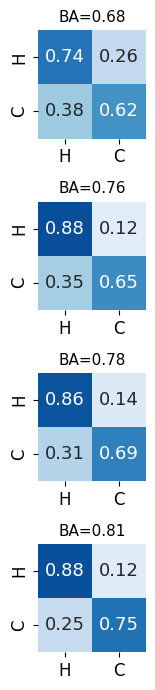

In [25]:
dfs = []

for plate in tqdm(use_plates):
  df, _, _ = eval_model(f'1_16_t01_healthy_cancer_without_plate_{plate}_by_cell_pretrained_subcell', 
                        test_healthy_vs_cancer_bagloader(use_plates=[plate], subcell_feats=True), FeatClassifier(input_dim=1536))
  df['plate'] = plate
  dfs.append(df)


res_without_df = pd.concat(dfs, ignore_index=True)

pat_df = res_without_df.groupby(['plate', 'pat', 'group'])['pred'].mean().reset_index()
diag = pd.read_csv('meta/patient_diagnosis_groups.csv').rename(columns={'patient':'pat', 'group':'diag'})
pat_df = pat_df.merge(diag, on='pat', how='left').set_index('pat')
pat_df.loc[pat_df['group'] == 'healthy', 'diag'] = 'healthy'

diags = ['CNS-Glioma', 'H&N cancer', 'Chordoma/Chondrosarcoma', 'CNS-Meningioma']
plates = [[1, 2], [3, 4, 5, 6], [10, 11, 12], [7, 8, 9]]

for d, ps in zip(diags, plates):
    pat_df.loc[pat_df['plate'].isin(ps) & ((pat_df['diag'] == d) | (pat_df['group'] == 'healthy')), 'diag_group'] = d

diag_df = pat_df.groupby(['diag_group', 'group'])['pred'].mean().reset_index()
diag_df.loc[diag_df['group'] != 'healthy', 'group'] = 'C'
diag_df.loc[diag_df['group'] == 'healthy', 'group'] = 'H'
diag_df['group'] = pd.Categorical(values=diag_df['group'], categories=['H', 'C'])
diag_df['H'] = diag_df['pred']
diag_df['C'] = 1 - diag_df['H']

fig, axs = plt.subplots(4, 1, figsize=(2.8, 7))
for ax, d, ps in zip(axs.flatten(), diags, plates):
    mat = diag_df[diag_df['diag_group'] == d].set_index('group').loc[['H', 'C'], ['H', 'C']]
    sns.heatmap(mat.div(mat.sum(axis=1), axis=0), annot=mat, ax=ax, vmin=0, vmax=1, cbar=False, cmap='Blues', square=True, annot_kws={'size': 13})
    ax.tick_params(labelsize=12)
    ax.set_title(soft_ba_title(mat), fontsize=11)
    ax.set_ylabel('')
    ax.set_xlabel('')
fig.tight_layout()

## Healthy vs. main cancer groups (timepoint 1)

In [26]:
from util import torch_random_choice


use_plates = np.array([3, 4, 5, 6, 7, 8, 9, 10, 11, 12])
short_groups = {'healthy' : 'H', 'H&N cancer' : 'H&N', 'CNS-Meningioma' : 'M', 
                'Chordoma/Chondrosarcoma' : 'C/C'}  
group_map = {'healthy' : 0, 'H&N cancer' : 1, 'CNS-Meningioma' : 2, 'Chordoma/Chondrosarcoma' : 3} 
use_groups = ['healthy', 'H&N cancer', 'CNS-Meningioma', 'Chordoma/Chondrosarcoma']
cdf = data.info[data.info['group'].isin(use_groups) & data.info['plate'].isin(use_plates)].groupby(
    ['patient', 'time'])['cell'].count().reset_index()
cdf = cdf[(cdf['cell'] > 100)]
p01s = cdf[(cdf['time'] == 1) | (cdf['time'] == 0)]['patient'].unique()


def test_group_bagloader(bag_size=100, use_patients=p01s, use_times=[0, 1], use_plates=use_plates, device=device, 
                         transform=T.CenterCrop(28), res_feats=False, dino_feats=False, dinobloom_feats=False, subcell_feats=False):
  use_idx = torch.argwhere(torch.from_numpy((data.info['plate'].isin(use_plates) & data.info['time'].isin(use_times)).values)).flatten()
  use_imgs = transform(data.imgs[use_idx].to(device))
  if res_feats:
    use_data = res_zs[use_idx].to(device)
  elif dino_feats:
    use_data = torch.from_numpy(data.dino_zs[use_idx]).to(device) 
  elif dinobloom_feats:
    use_data = torch.from_numpy(data.dinobloom_zs[use_idx]).to(device)
  elif subcell_feats:
    use_data = torch.from_numpy(data.subcell_zs[use_idx]).to(device)
  else: 
    use_data = use_imgs
  
  pat_groups = data.info.groupby(['patient'])['group'].max()
  pat_plates = data.info.groupby(['patient'])['plate'].unique()
  for pat in use_patients:
    if not np.isin(pat_plates[pat], use_plates).any():
      continue
    pat_idx = torch.argwhere(torch.from_numpy((data.info.loc[use_idx]['patient'] == pat).values)).flatten().to(device)
    idx = torch_random_choice(pat_idx, size=bag_size)
    xs = use_data[idx]
    label = pat_groups[pat]
    yield xs.float(), use_imgs[idx].float(), torch.tensor(group_map[label]).to(device), pat, label

In [27]:
from models import MultiFeatClassifier


def eval_model(name, loader, model, feats=True):
    model = model.to(device)
    model.load_state_dict(torch.load(f'/ewsc/hschluet/models/pbmc5/revision_rerun/{name}_model.pt', weights_only=True, map_location=device))
    model.eval()

    np.random.seed(1232412)
    torch.manual_seed(124514)
    torch.cuda.manual_seed_all(13513)

    bag_labs = []
    bag_pred = []
    bag_ids = []
    bag_zs = []
    bag_pats = []
    bag_groups = []
    bags = []
    for i, (z, bag, lab, pat, group) in enumerate(loader):
        with torch.no_grad():
            _, pred, z = model(z.to(device)) if feats else model(bag.to(device))
        bag_ids.extend([i] * 100)
        bag_pats.extend([pat] * 100)
        bag_groups.extend([group] * 100)
        bag_labs.extend([lab.item()] * 100)
        bag_pred.extend(pred.cpu().numpy())
        bag_zs.extend(z.cpu().numpy())
        bags.extend(bag.cpu().numpy())

    df = pd.DataFrame()
    df['lab'] = bag_labs
    df['pred'] = bag_pred
    df['i'] = bag_ids
    df['pat'] = bag_pats
    df['group'] = bag_groups
    return df, bag_zs, bags

### Fig. 2g

In [28]:
dfs = []

for plate in tqdm(use_plates):
  df, _, _ = eval_model(f'3_12_t01_healthy_cancer_without_plate_{plate}_by_cell_pretrained_resnet', 
                        test_group_bagloader(use_plates=[plate], res_feats=True), MultiFeatClassifier(classes=len(use_groups)))
  df['plate'] = plate
  dfs.append(df)


res_without_df = pd.concat(dfs, ignore_index=True)
pat_df = pd.DataFrame()
pat_df['counts'] = res_without_df.groupby(['plate', 'pat', 'group'])['pred'].value_counts() 
pat_df = pat_df.reset_index()
pat_df['pred'] = pd.Categorical(values=pat_df['pred'].map(lambda x: use_groups[x]).replace(short_groups), categories=['H', 'H&N', 'M', 'C/C'])
pat_df['group'] = pd.Categorical(values=pat_df['group'].replace(short_groups), categories=['H', 'H&N', 'M', 'C/C'])
pat_df

  0%|          | 0/10 [00:00<?, ?it/s]

 10%|█         | 1/10 [00:00<00:02,  3.61it/s]

 20%|██        | 2/10 [00:00<00:02,  3.44it/s]

 30%|███       | 3/10 [00:00<00:02,  2.89it/s]

 40%|████      | 4/10 [00:01<00:01,  3.09it/s]

...

 80%|████████  | 8/10 [00:02<00:00,  3.15it/s]

 90%|█████████ | 9/10 [00:02<00:00,  3.18it/s]

100%|██████████| 10/10 [00:03<00:00,  3.17it/s]

100%|██████████| 10/10 [00:03<00:00,  3.15it/s]

,plate,pat,group,pred,counts
0,3,H06,H,H,64
1,3,H06,H,H&N,22
2,3,H06,H,M,8
3,3,H06,H,C/C,6
4,3,H07,H,H,56
...,...,...,...,...,...
430,12,P155,C/C,H&N,8
431,12,P21,C/C,C/C,35
432,12,P21,C/C,H&N,32
433,12,P21,C/C,M,25


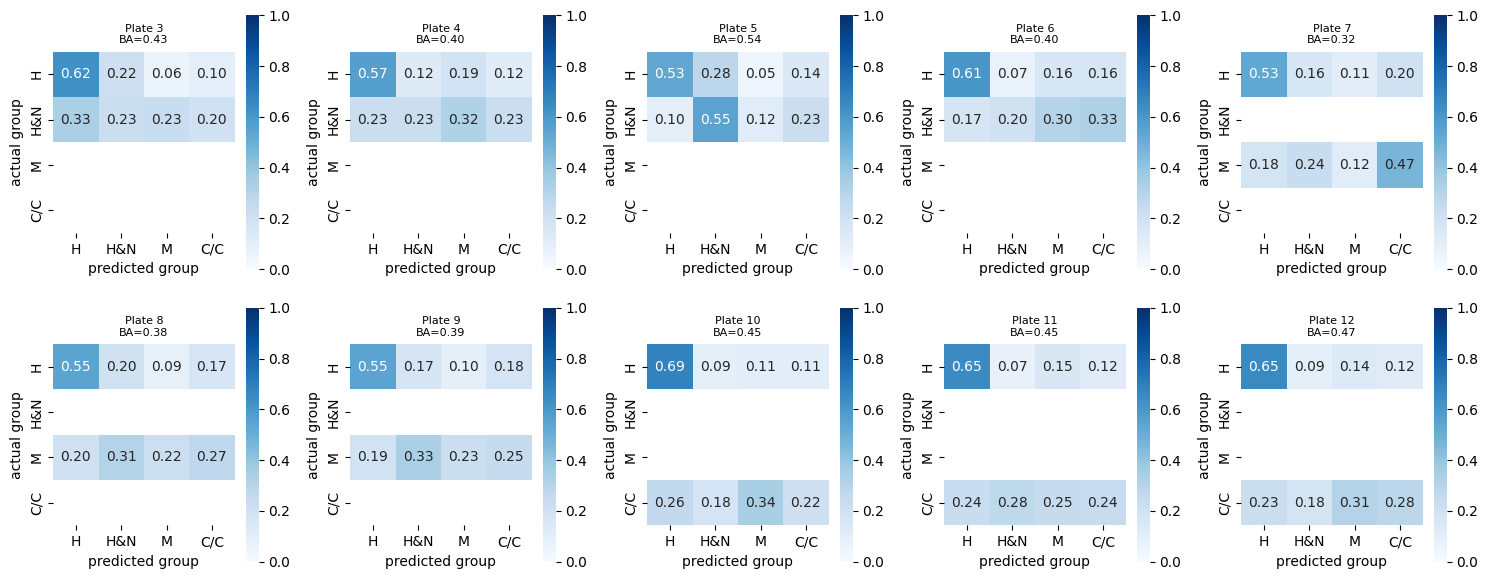

In [29]:
fig, axs = plt.subplots(2, 5, figsize=(15, 6))
for ax, plate in zip(axs.flatten(), use_plates):
    mat = pat_df[pat_df['plate'] == plate].groupby(
        ['group', 'pred'], observed=False)['counts'].sum().reset_index().pivot(index='group', columns='pred', values='counts')
    _cnt = mat
    mat = mat.div(mat.sum(axis=1), axis=0)
    sns.heatmap(mat, annot=mat, ax=ax, vmin=0, vmax=1, fmt="0.2f", cmap='Blues', square=True)
    ax.set_ylabel('actual group')
    ax.set_xlabel('predicted group')
    ax.set_title(f'Plate {plate}' + '\n' + cm_ba_title(_cnt), fontsize=8)
fig.tight_layout()

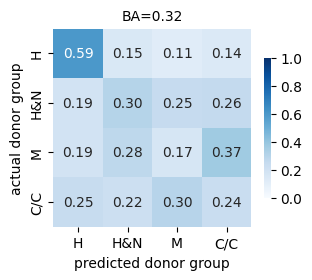

In [30]:
fig, ax = plt.subplots(1, 1, figsize=(3.3, 3))
mat = pat_df.groupby(
        ['group', 'pred'], observed=False)['counts'].sum().reset_index().pivot(index='group', columns='pred', values='counts')
_cnt = mat
mat = mat.div(mat.sum(axis=1), axis=0)
sns.heatmap(mat.div(mat.sum(axis=1), axis=0), annot=mat, ax=ax, vmin=0, vmax=1, fmt="0.2f", cmap='Blues', square=True, cbar_kws={'shrink': 0.6})
ax.set_title(cm_ba_title(_cnt), fontsize=plt.rcParams['xtick.labelsize'])
ax.set_ylabel('actual donor group')
ax.set_xlabel('predicted donor group')
fig.tight_layout()

### Fig. S2c

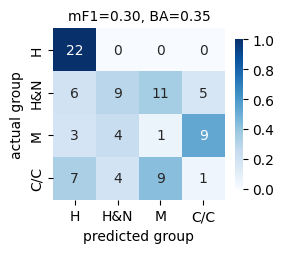

In [31]:
pat_vote_df = res_without_df.groupby(['pat', 'group'])['pred'].agg(lambda x : x.mode(dropna=True)[0]).dropna().reset_index()
pat_vote_df['pred'] = pd.Categorical(values=pat_vote_df['pred'].map(lambda x: use_groups[x]).replace(short_groups), categories=['H', 'H&N', 'M', 'C/C'])
pat_vote_df['group'] = pd.Categorical(values=pat_vote_df['group'].replace(short_groups), categories=['H', 'H&N', 'M', 'C/C'])

fig, ax = plt.subplots(1, 1, figsize=(3, 3))
mat = pat_vote_df.reset_index().groupby(
    ['group', 'pred'], observed=False)['pat'].count().reset_index().pivot(index='group', columns='pred', values='pat')
sns.heatmap(mat.div(mat.sum(axis=1), axis=0), annot=mat, ax=ax, vmin=0, vmax=1, cmap='Blues', square=True, cbar_kws={'shrink': 0.6})
ax.set_title(cm_metrics_title(mat), fontsize=plt.rcParams['xtick.labelsize'])
ax.set_ylabel('actual group')
ax.set_xlabel('predicted group')
fig.tight_layout()

### Fig. S2f (simple convnet)

In [32]:
from models import MultiClassifier

dfs = []

for plate in tqdm(use_plates):
  df, _, _ = eval_model(f'3_12_t01_healthy_groups_without_plate_{plate}_by_cell_mil_architecture', 
                        test_group_bagloader(use_plates=[plate]), 
                        MultiClassifier(classes=len(use_groups)), feats=False)
  df['plate'] = plate
  dfs.append(df)


res_without_df = pd.concat(dfs, ignore_index=True)
res_without_df

  0%|          | 0/10 [00:00<?, ?it/s]

 10%|█         | 1/10 [00:00<00:02,  3.36it/s]

 20%|██        | 2/10 [00:00<00:02,  3.08it/s]

 30%|███       | 3/10 [00:01<00:02,  2.56it/s]

 40%|████      | 4/10 [00:01<00:02,  2.34it/s]

...

 80%|████████  | 8/10 [00:03<00:01,  2.00it/s]

 90%|█████████ | 9/10 [00:04<00:00,  2.13it/s]

100%|██████████| 10/10 [00:04<00:00,  1.87it/s]

100%|██████████| 10/10 [00:04<00:00,  2.07it/s]

,lab,pred,i,pat,group,plate
0,0,0,0,H06,healthy,3
1,0,0,0,H06,healthy,3
2,0,1,0,H06,healthy,3
3,0,0,0,H06,healthy,3
4,0,1,0,H06,healthy,3
...,...,...,...,...,...,...
10895,3,2,6,P21,Chordoma/Chondrosarcoma,12
10896,3,3,6,P21,Chordoma/Chondrosarcoma,12
10897,3,3,6,P21,Chordoma/Chondrosarcoma,12
10898,3,1,6,P21,Chordoma/Chondrosarcoma,12


In [33]:
pat_df = pd.DataFrame()
pat_df['counts'] = res_without_df.groupby(['plate', 'pat', 'group'])['pred'].value_counts() 
pat_df = pat_df.reset_index()
pat_df['pred'] = pd.Categorical(values=pat_df['pred'].map(lambda x: use_groups[x]).replace(short_groups), categories=['H', 'H&N', 'M', 'C/C'])
pat_df['group'] = pd.Categorical(values=pat_df['group'].replace(short_groups), categories=['H', 'H&N', 'M', 'C/C'])
pat_df

,plate,pat,group,pred,counts
0,3,H06,H,H,71
1,3,H06,H,H&N,21
2,3,H06,H,M,4
3,3,H06,H,C/C,4
4,3,H07,H,H,63
...,...,...,...,...,...
429,12,P155,C/C,C/C,15
430,12,P21,C/C,M,41
431,12,P21,C/C,H&N,36
432,12,P21,C/C,C/C,16


/tmp/ipykernel_2658650/1729274495.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mat = pat_df[pat_df['plate'] == plate].groupby(


/tmp/ipykernel_2658650/1729274495.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mat = pat_df[pat_df['plate'] == plate].groupby(
/tmp/ipykernel_2658650/1729274495.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mat = pat_df[pat_df['plate'] == plate].groupby(


/tmp/ipykernel_2658650/1729274495.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mat = pat_df[pat_df['plate'] == plate].groupby(
/tmp/ipykernel_2658650/1729274495.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mat = pat_df[pat_df['plate'] == plate].groupby(


/tmp/ipykernel_2658650/1729274495.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mat = pat_df[pat_df['plate'] == plate].groupby(


/tmp/ipykernel_2658650/1729274495.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mat = pat_df[pat_df['plate'] == plate].groupby(


/tmp/ipykernel_2658650/1729274495.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mat = pat_df[pat_df['plate'] == plate].groupby(


/tmp/ipykernel_2658650/1729274495.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mat = pat_df[pat_df['plate'] == plate].groupby(


/tmp/ipykernel_2658650/1729274495.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mat = pat_df[pat_df['plate'] == plate].groupby(


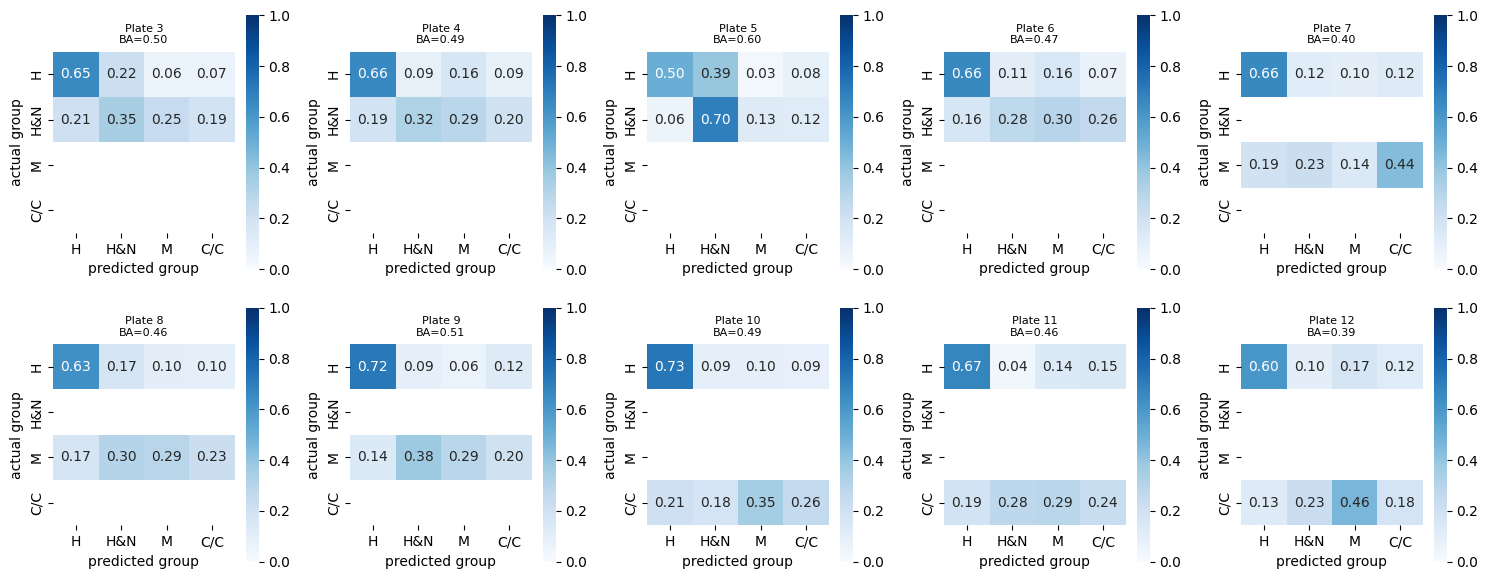

In [34]:
fig, axs = plt.subplots(2, 5, figsize=(15, 6))
for ax, plate in zip(axs.flatten(), use_plates):
    mat = pat_df[pat_df['plate'] == plate].groupby(
        ['group', 'pred'])['counts'].sum().reset_index().pivot(index='group', columns='pred', values='counts')
    _cnt = mat
    mat = mat.div(mat.sum(axis=1), axis=0)
    sns.heatmap(mat, annot=mat, ax=ax, vmin=0, vmax=1, fmt="0.2f", cmap='Blues', square=True)
    ax.set_ylabel('actual group')
    ax.set_xlabel('predicted group')
    ax.set_title(f'Plate {plate}' + '\n' + cm_ba_title(_cnt), fontsize=8)
fig.tight_layout()

/tmp/ipykernel_2658650/674138793.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mat = pat_df.groupby(


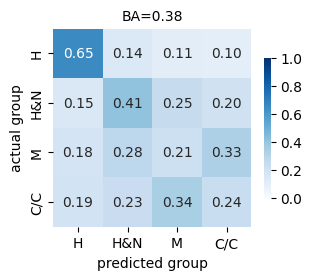

In [35]:
fig, ax = plt.subplots(1, 1, figsize=(3.3, 3))
mat = pat_df.groupby(
        ['group', 'pred'])['counts'].sum().reset_index().pivot(index='group', columns='pred', values='counts')
_cnt = mat
mat = mat.div(mat.sum(axis=1), axis=0)
sns.heatmap(mat.div(mat.sum(axis=1), axis=0), annot=mat, ax=ax, vmin=0, vmax=1, fmt="0.2f", cmap='Blues', square=True, cbar_kws={'shrink': 0.6})
ax.set_title(cm_ba_title(_cnt), fontsize=plt.rcParams['xtick.labelsize'])
ax.set_ylabel('actual group')
ax.set_xlabel('predicted group')
fig.tight_layout()

### Fig. S2f (resnet from scratch)

In [36]:
dfs = []

for plate in tqdm(use_plates):
  df, _, _ = eval_resnet(f'3_12_t01_healthy_groups_without_plate_{plate}_by_cell_resnet_from_scratch', 
                        test_group_bagloader(use_plates=[plate]), classes=len(use_groups))
  df['plate'] = plate
  dfs.append(df)


res_without_df = pd.concat(dfs, ignore_index=True)
res_without_df

  0%|          | 0/10 [00:00<?, ?it/s]

 10%|█         | 1/10 [00:01<00:10,  1.14s/it]

 20%|██        | 2/10 [00:02<00:10,  1.37s/it]

 30%|███       | 3/10 [00:03<00:09,  1.34s/it]

 40%|████      | 4/10 [00:05<00:07,  1.32s/it]

...

 80%|████████  | 8/10 [00:10<00:02,  1.38s/it]

 90%|█████████ | 9/10 [00:12<00:01,  1.32s/it]

100%|██████████| 10/10 [00:13<00:00,  1.38s/it]

100%|██████████| 10/10 [00:13<00:00,  1.36s/it]

,lab,pred,i,pat,group,plate
0,0,0,0,H06,healthy,3
1,0,0,0,H06,healthy,3
2,0,0,0,H06,healthy,3
3,0,0,0,H06,healthy,3
4,0,0,0,H06,healthy,3
...,...,...,...,...,...,...
10895,3,2,6,P21,Chordoma/Chondrosarcoma,12
10896,3,3,6,P21,Chordoma/Chondrosarcoma,12
10897,3,1,6,P21,Chordoma/Chondrosarcoma,12
10898,3,3,6,P21,Chordoma/Chondrosarcoma,12


In [37]:
pat_df = pd.DataFrame()
pat_df['counts'] = res_without_df.groupby(['plate', 'pat', 'group'])['pred'].value_counts() 
pat_df = pat_df.reset_index()
pat_df['pred'] = pd.Categorical(values=pat_df['pred'].map(lambda x: use_groups[x]).replace(short_groups), categories=['H', 'H&N', 'M', 'C/C'])
pat_df['group'] = pd.Categorical(values=pat_df['group'].replace(short_groups), categories=['H', 'H&N', 'M', 'C/C'])
pat_df

,plate,pat,group,pred,counts
0,3,H06,H,H,82
1,3,H06,H,H&N,10
2,3,H06,H,M,6
3,3,H06,H,C/C,2
4,3,H07,H,H,87
...,...,...,...,...,...
414,12,P155,C/C,H&N,13
415,12,P21,C/C,M,65
416,12,P21,C/C,H&N,23
417,12,P21,C/C,C/C,10


/tmp/ipykernel_2658650/1729274495.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mat = pat_df[pat_df['plate'] == plate].groupby(


/tmp/ipykernel_2658650/1729274495.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mat = pat_df[pat_df['plate'] == plate].groupby(
/tmp/ipykernel_2658650/1729274495.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mat = pat_df[pat_df['plate'] == plate].groupby(


/tmp/ipykernel_2658650/1729274495.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mat = pat_df[pat_df['plate'] == plate].groupby(
/tmp/ipykernel_2658650/1729274495.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mat = pat_df[pat_df['plate'] == plate].groupby(


/tmp/ipykernel_2658650/1729274495.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mat = pat_df[pat_df['plate'] == plate].groupby(
/tmp/ipykernel_2658650/1729274495.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mat = pat_df[pat_df['plate'] == plate].groupby(


/tmp/ipykernel_2658650/1729274495.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mat = pat_df[pat_df['plate'] == plate].groupby(


/tmp/ipykernel_2658650/1729274495.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mat = pat_df[pat_df['plate'] == plate].groupby(


/tmp/ipykernel_2658650/1729274495.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mat = pat_df[pat_df['plate'] == plate].groupby(


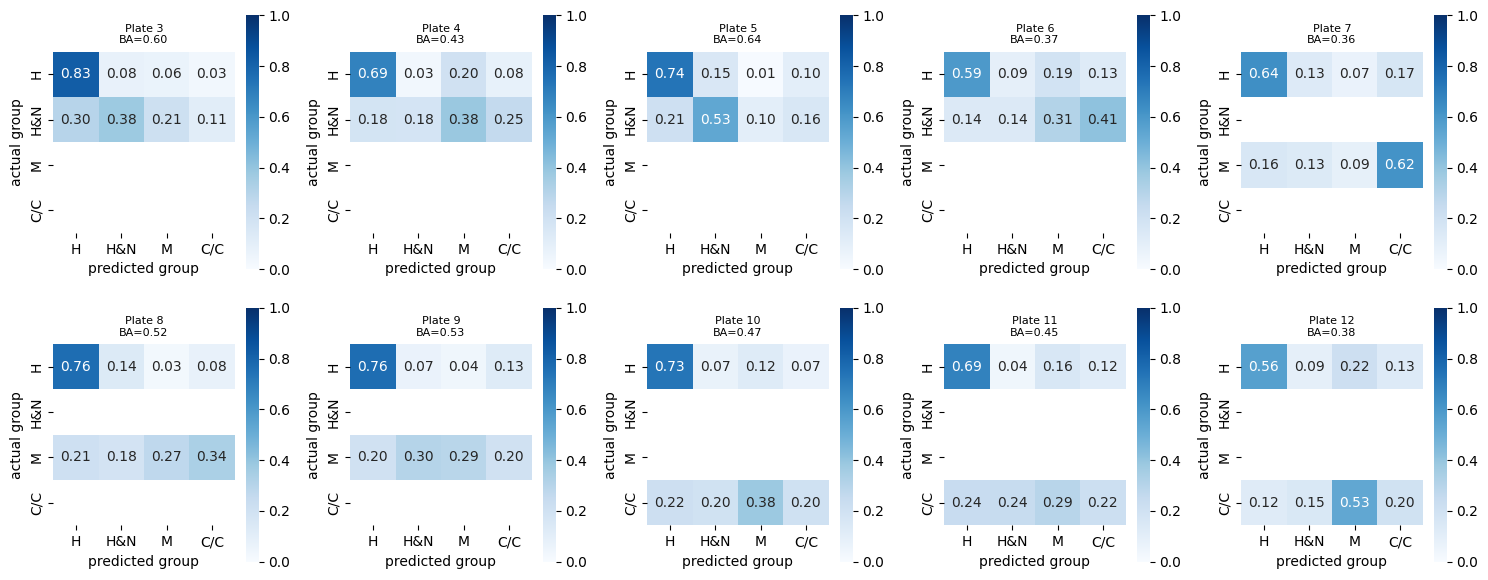

In [38]:
fig, axs = plt.subplots(2, 5, figsize=(15, 6))
for ax, plate in zip(axs.flatten(), use_plates):
    mat = pat_df[pat_df['plate'] == plate].groupby(
        ['group', 'pred'])['counts'].sum().reset_index().pivot(index='group', columns='pred', values='counts')
    _cnt = mat
    mat = mat.div(mat.sum(axis=1), axis=0)
    sns.heatmap(mat, annot=mat, ax=ax, vmin=0, vmax=1, fmt="0.2f", cmap='Blues', square=True)
    ax.set_ylabel('actual group')
    ax.set_xlabel('predicted group')
    ax.set_title(f'Plate {plate}' + '\n' + cm_ba_title(_cnt), fontsize=8)
fig.tight_layout()

/tmp/ipykernel_2658650/674138793.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mat = pat_df.groupby(


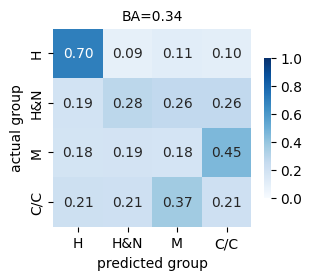

In [39]:
fig, ax = plt.subplots(1, 1, figsize=(3.3, 3))
mat = pat_df.groupby(
        ['group', 'pred'])['counts'].sum().reset_index().pivot(index='group', columns='pred', values='counts')
_cnt = mat
mat = mat.div(mat.sum(axis=1), axis=0)
sns.heatmap(mat.div(mat.sum(axis=1), axis=0), annot=mat, ax=ax, vmin=0, vmax=1, fmt="0.2f", cmap='Blues', square=True, cbar_kws={'shrink': 0.6})
ax.set_title(cm_ba_title(_cnt), fontsize=plt.rcParams['xtick.labelsize'])
ax.set_ylabel('actual group')
ax.set_xlabel('predicted group')
fig.tight_layout()

### Fig. 2f (pre-trained DINO)

In [40]:
dfs = []

for plate in tqdm(use_plates):
  df, _, _ = eval_model(f'3_12_t01_healthy_cancer_without_plate_{plate}_by_cell_pretrained_dino', 
                        test_group_bagloader(use_plates=[plate], dino_feats=True), MultiFeatClassifier(classes=len(use_groups), input_dim=384))
  df['plate'] = plate
  dfs.append(df)


res_without_df = pd.concat(dfs, ignore_index=True)
pat_df = pd.DataFrame()
pat_df['counts'] = res_without_df.groupby(['plate', 'pat', 'group'])['pred'].value_counts() 
pat_df = pat_df.reset_index()
pat_df['pred'] = pd.Categorical(values=pat_df['pred'].map(lambda x: use_groups[x]).replace(short_groups), categories=['H', 'H&N', 'M', 'C/C'])
pat_df['group'] = pd.Categorical(values=pat_df['group'].replace(short_groups), categories=['H', 'H&N', 'M', 'C/C'])
pat_df

  0%|          | 0/10 [00:00<?, ?it/s]

 10%|█         | 1/10 [00:00<00:02,  3.23it/s]

 20%|██        | 2/10 [00:00<00:03,  2.23it/s]

 30%|███       | 3/10 [00:01<00:02,  2.39it/s]

 40%|████      | 4/10 [00:01<00:02,  2.36it/s]

...

 80%|████████  | 8/10 [00:03<00:00,  2.14it/s]

 90%|█████████ | 9/10 [00:04<00:00,  2.16it/s]

100%|██████████| 10/10 [00:04<00:00,  2.00it/s]

100%|██████████| 10/10 [00:04<00:00,  2.09it/s]

,plate,pat,group,pred,counts
0,3,H06,H,H,53
1,3,H06,H,H&N,32
2,3,H06,H,C/C,13
3,3,H06,H,M,2
4,3,H07,H,H,60
...,...,...,...,...,...
429,12,P155,C/C,C/C,15
430,12,P21,C/C,M,36
431,12,P21,C/C,H&N,29
432,12,P21,C/C,C/C,23


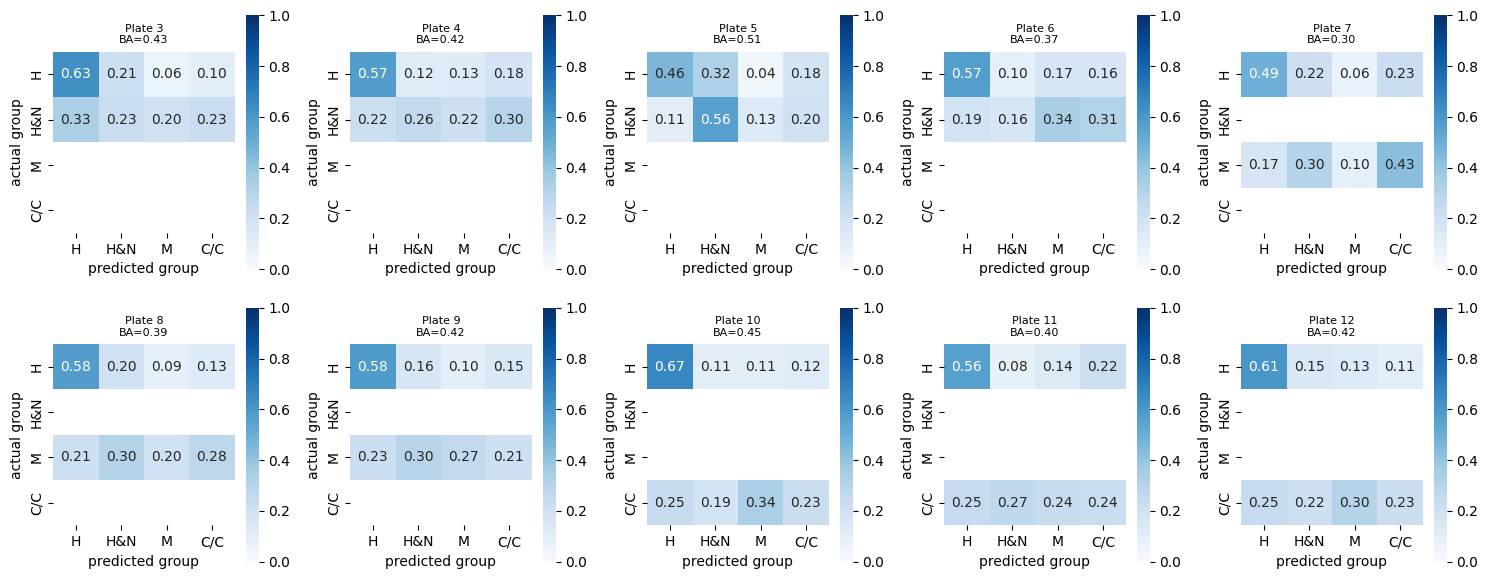

In [41]:
fig, axs = plt.subplots(2, 5, figsize=(15, 6))
for ax, plate in zip(axs.flatten(), use_plates):
    mat = pat_df[pat_df['plate'] == plate].groupby(
        ['group', 'pred'], observed=False)['counts'].sum().reset_index().pivot(index='group', columns='pred', values='counts')
    _cnt = mat
    mat = mat.div(mat.sum(axis=1), axis=0)
    sns.heatmap(mat, annot=mat, ax=ax, vmin=0, vmax=1, fmt="0.2f", cmap='Blues', square=True)
    ax.set_ylabel('actual group')
    ax.set_xlabel('predicted group')
    ax.set_title(f'Plate {plate}' + '\n' + cm_ba_title(_cnt), fontsize=8)
fig.tight_layout()

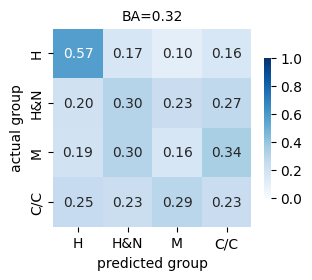

In [42]:
fig, ax = plt.subplots(1, 1, figsize=(3.3, 3))
mat = pat_df.groupby(
        ['group', 'pred'], observed=False)['counts'].sum().reset_index().pivot(index='group', columns='pred', values='counts')
_cnt = mat
mat = mat.div(mat.sum(axis=1), axis=0)
sns.heatmap(mat.div(mat.sum(axis=1), axis=0), annot=mat, ax=ax, vmin=0, vmax=1, fmt="0.2f", cmap='Blues', square=True, cbar_kws={'shrink': 0.6})
ax.set_title(cm_ba_title(_cnt), fontsize=plt.rcParams['xtick.labelsize'])
ax.set_ylabel('actual group')
ax.set_xlabel('predicted group')
fig.tight_layout()

### Fig. S2f (DinoBloom-S)

  0%|          | 0/10 [00:00<?, ?it/s]

 10%|█         | 1/10 [00:00<00:03,  2.57it/s]

 20%|██        | 2/10 [00:00<00:02,  2.86it/s]

 30%|███       | 3/10 [00:01<00:02,  2.95it/s]

 40%|████      | 4/10 [00:01<00:02,  2.95it/s]

...

 70%|███████   | 7/10 [00:02<00:01,  2.44it/s]

 80%|████████  | 8/10 [00:03<00:00,  2.45it/s]

 90%|█████████ | 9/10 [00:03<00:00,  2.68it/s]

100%|██████████| 10/10 [00:03<00:00,  2.62it/s]

100%|██████████| 10/10 [00:03<00:00,  2.54it/s]

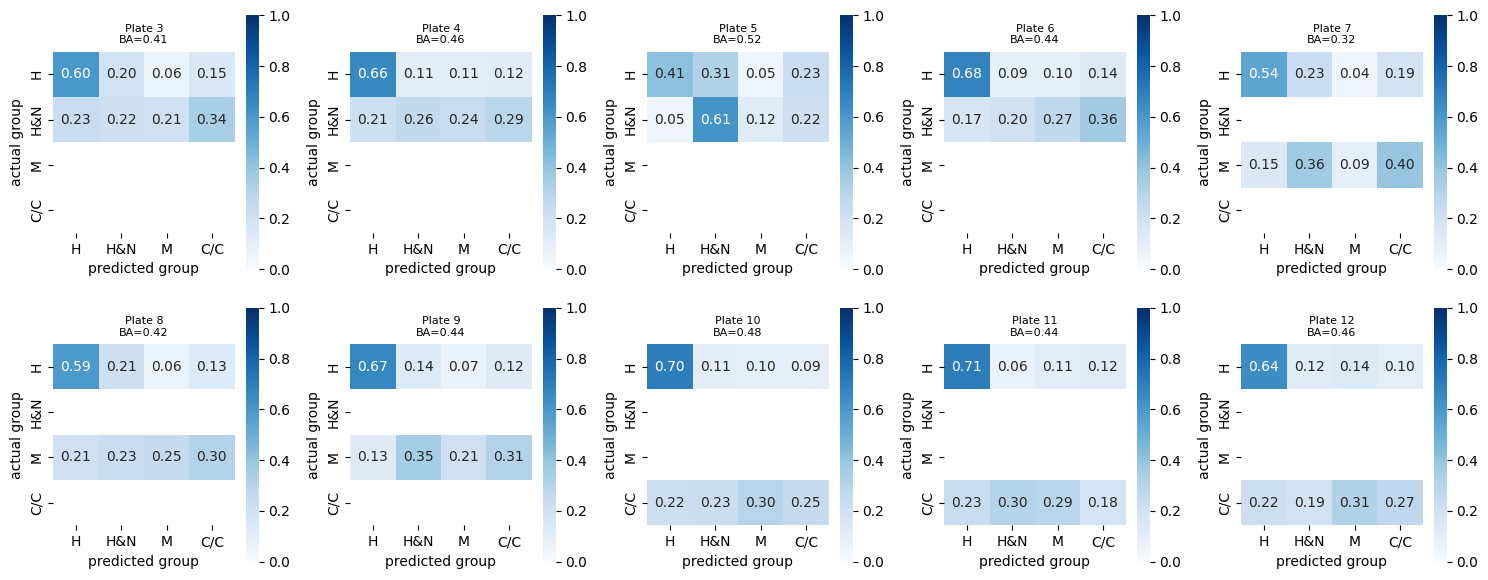

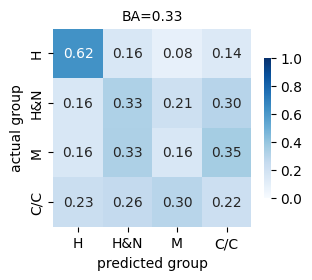

In [43]:
dfs = []

for plate in tqdm(use_plates):
  df, _, _ = eval_model(f'3_12_t01_healthy_cancer_without_plate_{plate}_by_cell_pretrained_dinobloom', 
                        test_group_bagloader(use_plates=[plate], dinobloom_feats=True), MultiFeatClassifier(classes=len(use_groups), input_dim=384))
  df['plate'] = plate
  dfs.append(df)


res_without_df = pd.concat(dfs, ignore_index=True)
pat_df = pd.DataFrame()
pat_df['counts'] = res_without_df.groupby(['plate', 'pat', 'group'])['pred'].value_counts() 
pat_df = pat_df.reset_index()
pat_df['pred'] = pd.Categorical(values=pat_df['pred'].map(lambda x: use_groups[x]).replace(short_groups), categories=['H', 'H&N', 'M', 'C/C'])
pat_df['group'] = pd.Categorical(values=pat_df['group'].replace(short_groups), categories=['H', 'H&N', 'M', 'C/C'])

fig, axs = plt.subplots(2, 5, figsize=(15, 6))
for ax, plate in zip(axs.flatten(), use_plates):
    mat = pat_df[pat_df['plate'] == plate].groupby(
        ['group', 'pred'], observed=False)['counts'].sum().reset_index().pivot(index='group', columns='pred', values='counts')
    _cnt = mat
    mat = mat.div(mat.sum(axis=1), axis=0)
    sns.heatmap(mat, annot=mat, ax=ax, vmin=0, vmax=1, fmt="0.2f", cmap='Blues', square=True)
    ax.set_ylabel('actual group')
    ax.set_xlabel('predicted group')
    ax.set_title(f'Plate {plate}' + '\n' + cm_ba_title(_cnt), fontsize=8)
fig.tight_layout()


fig, ax = plt.subplots(1, 1, figsize=(3.3, 3))
mat = pat_df.groupby(
        ['group', 'pred'], observed=False)['counts'].sum().reset_index().pivot(index='group', columns='pred', values='counts')
_cnt = mat
mat = mat.div(mat.sum(axis=1), axis=0)
sns.heatmap(mat.div(mat.sum(axis=1), axis=0), annot=mat, ax=ax, vmin=0, vmax=1, fmt="0.2f", cmap='Blues', square=True, cbar_kws={'shrink': 0.6})
ax.set_title(cm_ba_title(_cnt), fontsize=plt.rcParams['xtick.labelsize'])
ax.set_ylabel('actual group')
ax.set_xlabel('predicted group')
fig.tight_layout()

### Fig. S2f (SubCell)

  0%|          | 0/10 [00:00<?, ?it/s]

 10%|█         | 1/10 [00:00<00:06,  1.30it/s]

 20%|██        | 2/10 [00:01<00:07,  1.04it/s]

 30%|███       | 3/10 [00:02<00:06,  1.16it/s]

 40%|████      | 4/10 [00:03<00:05,  1.08it/s]

...

 70%|███████   | 7/10 [00:07<00:03,  1.09s/it]

 80%|████████  | 8/10 [00:08<00:02,  1.06s/it]

 90%|█████████ | 9/10 [00:09<00:01,  1.09s/it]

100%|██████████| 10/10 [00:10<00:00,  1.16s/it]

100%|██████████| 10/10 [00:10<00:00,  1.07s/it]

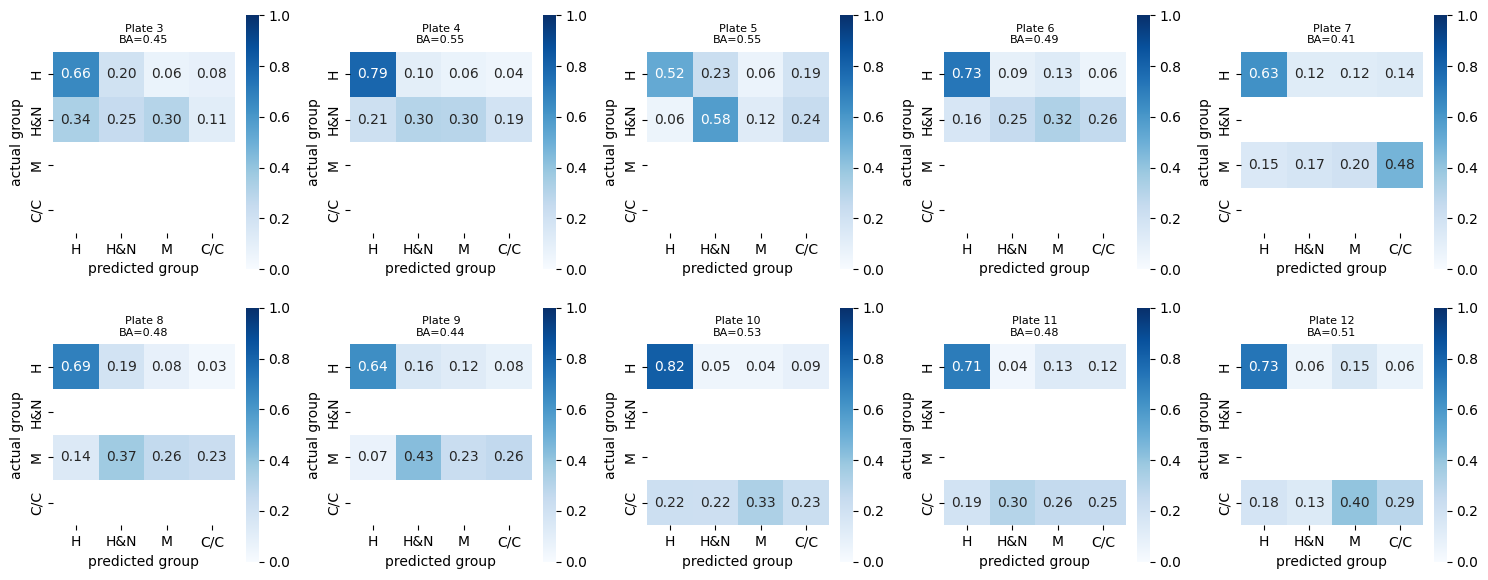

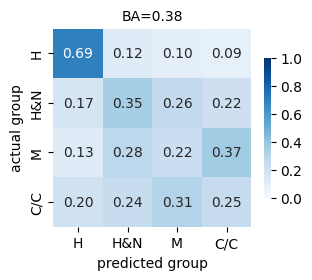

In [44]:
dfs = []

for plate in tqdm(use_plates):
  df, _, _ = eval_model(f'3_12_t01_healthy_cancer_without_plate_{plate}_by_cell_pretrained_subcell', 
                        test_group_bagloader(use_plates=[plate], subcell_feats=True), MultiFeatClassifier(classes=len(use_groups), input_dim=1536))
  df['plate'] = plate
  dfs.append(df)


res_without_df = pd.concat(dfs, ignore_index=True)
pat_df = pd.DataFrame()
pat_df['counts'] = res_without_df.groupby(['plate', 'pat', 'group'])['pred'].value_counts() 
pat_df = pat_df.reset_index()
pat_df['pred'] = pd.Categorical(values=pat_df['pred'].map(lambda x: use_groups[x]).replace(short_groups), categories=['H', 'H&N', 'M', 'C/C'])
pat_df['group'] = pd.Categorical(values=pat_df['group'].replace(short_groups), categories=['H', 'H&N', 'M', 'C/C'])

fig, axs = plt.subplots(2, 5, figsize=(15, 6))
for ax, plate in zip(axs.flatten(), use_plates):
    mat = pat_df[pat_df['plate'] == plate].groupby(
        ['group', 'pred'], observed=False)['counts'].sum().reset_index().pivot(index='group', columns='pred', values='counts')
    _cnt = mat
    mat = mat.div(mat.sum(axis=1), axis=0)
    sns.heatmap(mat, annot=mat, ax=ax, vmin=0, vmax=1, fmt="0.2f", cmap='Blues', square=True)
    ax.set_ylabel('actual group')
    ax.set_xlabel('predicted group')
    ax.set_title(f'Plate {plate}' + '\n' + cm_ba_title(_cnt), fontsize=8)
fig.tight_layout()


fig, ax = plt.subplots(1, 1, figsize=(3.3, 3))
mat = pat_df.groupby(
        ['group', 'pred'], observed=False)['counts'].sum().reset_index().pivot(index='group', columns='pred', values='counts')
_cnt = mat
mat = mat.div(mat.sum(axis=1), axis=0)
sns.heatmap(mat.div(mat.sum(axis=1), axis=0), annot=mat, ax=ax, vmin=0, vmax=1, fmt="0.2f", cmap='Blues', square=True, cbar_kws={'shrink': 0.6})
ax.set_title(cm_ba_title(_cnt), fontsize=plt.rcParams['xtick.labelsize'])
ax.set_ylabel('actual group')
ax.set_xlabel('predicted group')
fig.tight_layout()